<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>51095 למידה מונחית חיזוקים</p>
<p>פרויקט סופי</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נושא: מימוש מאפס של אלגוריתם Monte Carlo Tree Search למשחקי לוח לשני שחקנים, על שתי סביבות: איקס עיגול כסביבת אימות שהפתרון המושלם שלה ידוע, וארבע בשורה מוקטן (4 שורות, 5 עמודות) כסביבת הניסוי המרכזית.</p>
<p>שאלת המחקר: כמה חיפוש נדרש כדי לגבור על שחקנים פשוטים ולהתקרב למשחק מושלם, ומה משתפר כאשר הסימולציה האקראית מוחלפת ברשת נוירונים שלומדת ערך ומדיניות מתוך משחקי האלגוריתם נגד עצמו.</p>
<p>גישה: שלב 1 — MCTS טהור מול שחקן אקראי, שחקן חמדן ושחקן מושלם מבוסס minimax, כולל אבלציות על מספר הסימולציות ועל עומק ה-rollout. שלב 2 — רשת policy ו-value קטנה המאומנת בלמידה מפוקחת על תוצרי החיפוש ומשולבת בהערכת עלים במקום סימולציה אקראית, ברוח AlphaZero.</p>
<p>מדדים: אחוזי ניצחון, הפסד ותיקו מול שחקני הבסיס, מספר הפסדים מול שחקן מושלם, אחוז מהלכים אופטימליים באיקס עיגול, ועקומות למידה לאורך סבבי האימון בשלב 2.</p>
<p>הגדרת הסביבה: מצב הוא תוכן הלוח בתוספת זהות השחקן שתורו לשחק. פעולה באיקס עיגול היא בחירת משבצת ריקה, ובארבע בשורה בחירת עמודה שאינה מלאה, כשהאסימון נופל לשורה הפנויה הנמוכה ביותר. התגמול ניתן רק בסיום המשחק: 1 ניצחון, מינוס 1 הפסד, 0 תיקו, מנקודת מבטו של כל שחקן. המשחק מסתיים ברצף מנצח או בלוח מלא.</p>
<p>מבנה המחברת: כל הקוד נמצא במחברת עצמה בהתאם לדרישות ההגשה, ללא קבצים חיצוניים וללא חיבור לדרייב, כך שהרצה מלאה מהתחלה ועד הסוף משחזרת את כל התוצאות. גרפים נכתבים באנגלית מכיוון ש-matplotlib אינה מציגה עברית כראוי, וההסבר לכל גרף ניתן בתא טקסט צמוד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא ספריות — כל הייבוא של הפרויקט מרוכז בתא אחד ולא מתווסף ייבוא נוסף בהמשך:</p>
<ul>
<li>math, random, time — שורש ריבועי ולוגריתם לנוסחאות החיפוש, בחירות אקראיות אצל השחקנים ובסימולציות, ומדידת זמני ריצה</li>
<li>pickle, deepcopy — שמירת תוצאות ניסויים ומודלים מאומנים לשימוש חוזר, ושכפול עמוק כגיבוי</li>
<li>numpy — ייצוג הלוח של ארבע בשורה, וקטורי מדיניות וחישובים סטטיסטיים</li>
<li>matplotlib — כל הגרפים במחברת</li>
<li>seaborn — מפות חום של המדיניות הנלמדת בשלב 2; סגנון הגרפים הכללי נקבע בשורה האחרונה של תא הייבוא</li>
<li>torch, nn, F — בניית רשת הנוירונים ואימונה בשלב 2</li>
</ul>
</div>

In [ ]:
import math
import random
import time
import pickle
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.style.use("ggplot")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרות כלליות — כל הפרמטרים של הפרויקט במקום אחד, ומשמעות כל אחד:</p>
<ul>
<li>SEED — הזרע הראשי; קיבועו עבור random, numpy ו-torch מבטיח שחזור מלא של התוצאות</li>
<li>C4_ROWS, C4_COLS, C4_CONNECT — ממדי ארבע בשורה המוקטן: 4 שורות, 5 עמודות ורצף מנצח באורך 4</li>
<li>UCT_C — קבוע החקר בנוסחת UCT; שורש 2 הוא הערך התאורטי המקובל</li>
<li>N_SIMULATIONS — מספר הסימולציות לכל מהלך של אלגוריתם החיפוש, כברירת מחדל</li>
<li>EVAL_GAMES, VALIDATION_GAMES — מספרי משחקים בהערכות סטטיסטיות ובבדיקות האימות</li>
<li>SEEDS — רשימת זרעים לחזרות על ניסויים לצורך ממוצע וסטיית תקן</li>
<li>SIM_COUNTS, ABLATION_GAMES — ערכי מספר הסימולציות שנבחנים באבלציה ומספר המשחקים לכל זרע בכל נקודה</li>
<li>PUCT_C — קבוע החקר בנוסחת PUCT של החיפוש מונחה הרשת בשלב 2</li>
<li>HIDDEN_SIZE, LEARNING_RATE, TRAIN_EPOCHS, BATCH_SIZE — היפר-פרמטרים של רשת הנוירונים ואימונה</li>
<li>BUFFER_SIZE — גודל מאגר הדוגמאות המתגלגל שממנו הרשת מתאמנת</li>
<li>TEMPERATURE_MOVES — מספר המהלכים הראשונים בכל משחק עצמי שבהם המהלך נדגם לפי התפלגות הביקורים, לצורך גיוון הדאטה</li>
<li>DIRICHLET_ALPHA, DIRICHLET_EPS — פרמטרי רעש דיריכלה שמוזרק להסתברויות בשורש בזמן משחק עצמי, לעידוד חקר</li>
<li>SELFPLAY_SIMS, TRAIN_ITERATIONS, GAMES_PER_ITERATION, EVAL_GAMES_PER_ITERATION — תקציב החיפוש במשחק העצמי, מספר סבבי האימון, מספר המשחקים בכל סבב ומספר משחקי ההערכה אחרי כל סבב</li>
<li>RETRAIN — דגל הרצה: True מריץ את הניסויים הכבדים ושומר את התוצאות לקבצים, False טוען את התוצאות השמורות במקום להריץ מחדש</li>
<li>DEVICE — בחירה אוטומטית של מעבד גרפי אם קיים, לאימון הרשת</li>
</ul>
</div>

In [ ]:
SEED = 42
C4_ROWS = 4
C4_COLS = 5
C4_CONNECT = 4
UCT_C = math.sqrt(2)
N_SIMULATIONS = 200
EVAL_GAMES = 200
VALIDATION_GAMES = 50
SEEDS = [0, 1, 2, 3, 4]
SIM_COUNTS = [10, 25, 50, 100, 200, 400]
ABLATION_GAMES = 30
PUCT_C = 1.5
HIDDEN_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 4
BATCH_SIZE = 64
BUFFER_SIZE = 2500
TEMPERATURE_MOVES = 2
DIRICHLET_ALPHA = 0.3
DIRICHLET_EPS = 0.25
SELFPLAY_SIMS = 60
TRAIN_ITERATIONS = 15
GAMES_PER_ITERATION = 30
EVAL_GAMES_PER_ITERATION = 15
RETRAIN = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סביבות המשחק — ממשק אחיד לשני המשחקים:</p>
<p>שתי הסביבות ממומשות עם אותן חמש פונקציות בדיוק, ולכן האלגוריתמים בהמשך אינם תלויים בזהות המשחק ורצים על שתיהן ללא שינוי. השחקנים מסומנים 1 ומינוס 1 ומשבצת ריקה מסומנת 0. מכיוון שמחלקה חייבת להיות מוגדרת בתא אחד, ההסבר על כל פונקציה מופיע בתא הטקסט שלפני כל מחלקה.</p>
<p>הסביבות ממומשות עצמאית ולא באמצעות Gymnasium: ממשק ה-reset וה-step של Gymnasium מיועד לסוכן יחיד מול סביבה ואינו מספק שכפול מצבים, בעוד ש-MCTS דורש מודל קדימה עם עותקי מצב זולים ומשחק תורות בין שני שחקנים. בנוסף, שני המשחקים אינם קיימים ב-Gymnasium. מסמך הפרויקט מתיר במפורש סביבה עצמאית, ומימוש הסביבה הוא חלק מהמימוש העצמאי הנדרש.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה TicTacToe — איקס עיגול על לוח 3 על 3 המיוצג כרשימה שטוחה באורך 9:</p>
<ul>
<li>LINES — שמונה שלשות האינדקסים שיוצרות שורה מנצחת: שלוש שורות, שלוש עמודות ושני אלכסונים</li>
<li>init — יוצרת לוח ריק וקובעת שהשחקן הפותח הוא 1</li>
<li>clone — עותק בלתי תלוי של המצב, כדי לנסות מהלכים מבלי לשנות את המשחק המקורי; נדרש לשחקן החמדן ולסימולציות של החיפוש</li>
<li>legal_moves — רשימת האינדקסים של המשבצות הריקות</li>
<li>play — מציבה את סימן השחקן הנוכחי במשבצת שנבחרה ומעבירה את התור על ידי היפוך הסימן</li>
<li>winner — סורקת את שמונה הקווים: סכום 3 הוא ניצחון של שחקן 1, סכום מינוס 3 של השחקן השני, לוח מלא ללא מנצח הוא תיקו שמסומן 0, ואחרת המשחק נמשך ומוחזר None</li>
<li>render — מדפיסה את הלוח עם X, O ונקודה למשבצת ריקה</li>
</ul>
</div>

In [ ]:
class TicTacToe:
    LINES = ((0, 1, 2), (3, 4, 5), (6, 7, 8),
             (0, 3, 6), (1, 4, 7), (2, 5, 8),
             (0, 4, 8), (2, 4, 6))

    def __init__(self):
        self.board = [0] * 9
        self.player = 1

    def clone(self):
        g = TicTacToe()
        g.board = self.board[:]
        g.player = self.player
        return g

    def legal_moves(self):
        return [i for i in range(9) if self.board[i] == 0]

    def play(self, move):
        self.board[move] = self.player
        self.player = -self.player

    def winner(self):
        for a, b, c in self.LINES:
            s = self.board[a] + self.board[b] + self.board[c]
            if s == 3:
                return 1
            if s == -3:
                return -1
        if 0 not in self.board:
            return 0
        return None

    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        for r in range(3):
            print(" ".join(symbols[self.board[3 * r + c]] for c in range(3)))
        print()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה ConnectFour — ארבע בשורה מוקטן על מטריצה של 4 שורות ו-5 עמודות, כאשר שורה 0 היא העליונה:</p>
<ul>
<li>init — יוצרת לוח ריק, קובעת את השחקן הפותח ושומרת את המהלך האחרון, שמתחיל כ-None</li>
<li>clone — עותק בלתי תלוי של המצב, כולל עותק של המטריצה ושל המהלך האחרון</li>
<li>legal_moves — העמודות שהמשבצת העליונה שלהן עדיין ריקה</li>
<li>play — מממשת את הכבידה: האסימון מוצב בשורה הפנויה הנמוכה ביותר בעמודה שנבחרה, המהלך נשמר לצורך בדיקת הניצחון, והתור עובר</li>
<li>winner — בודקת ניצחון סביב המהלך האחרון בלבד, כי רק הוא יכול ליצור רצף חדש; בכל אחד מארבעה כיוונים נספר אורך הרצף לשני צידי האסימון שהונח; רצף באורך 4 מחזיר את המנצח, לוח ללא מהלכים חוקיים מחזיר תיקו, ואחרת המשחק נמשך</li>
<li>render — מדפיסה את הלוח ומתחתיו את מספרי העמודות</li>
</ul>
</div>

In [ ]:
class ConnectFour:
    def __init__(self, rows=C4_ROWS, cols=C4_COLS, connect=C4_CONNECT):
        self.rows = rows
        self.cols = cols
        self.connect = connect
        self.board = np.zeros((rows, cols), dtype=int)
        self.player = 1
        self.last_move = None

    def clone(self):
        g = ConnectFour(self.rows, self.cols, self.connect)
        g.board = self.board.copy()
        g.player = self.player
        g.last_move = self.last_move
        return g

    def legal_moves(self):
        return [c for c in range(self.cols) if self.board[0, c] == 0]

    def play(self, col):
        row = max(r for r in range(self.rows) if self.board[r, col] == 0)
        self.board[row, col] = self.player
        self.last_move = (row, col, self.player)
        self.player = -self.player

    def winner(self):
        if self.last_move is None:
            return None
        row, col, player = self.last_move
        for dr, dc in ((0, 1), (1, 0), (1, 1), (1, -1)):
            count = 1
            for sign in (1, -1):
                r, c = row + sign * dr, col + sign * dc
                while 0 <= r < self.rows and 0 <= c < self.cols and self.board[r, c] == player:
                    count += 1
                    r += sign * dr
                    c += sign * dc
            if count >= self.connect:
                return player
        if len(self.legal_moves()) == 0:
            return 0
        return None

    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        for r in range(self.rows):
            print(" ".join(symbols[int(self.board[r, c])] for c in range(self.cols)))
        print(" ".join(str(c) for c in range(self.cols)))
        print()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שחקני בסיס:</p>
<p>שחקן מיוצג כפונקציה שמקבלת מצב משחק ומחזירה מהלך חוקי. הודות למוסכמה הזו, גם אלגוריתמי החיפוש בהמשך ייארזו כפונקציות כאלה, וכל הסוכנים יוכלו להתמודד זה מול זה באותו מנגנון בדיוק.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה random_player בוחרת מהלך אחיד מבין המהלכים החוקיים. זהו היריב החלש ביותר והוא משמש קו בסיס תחתון: כל אלגוריתם בהמשך חייב לגבור עליו בבירור.</p>
</div>

In [ ]:
def random_player(game):
    return random.choice(game.legal_moves())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה winning_moves מאתרת את כל המהלכים שמנצחים מיד עבור שחקן נתון. היא עוברת על כל מהלך חוקי, משכפלת את המצב, קובעת בעותק את השחקן המבוקש, מבצעת את המהלך ובודקת אם נוצר ניצחון. השכפול מבטיח שהמשחק האמיתי אינו משתנה במהלך הבדיקה.</p>
</div>

In [ ]:
def winning_moves(game, player):
    moves = []
    for move in game.legal_moves():
        g = game.clone()
        g.player = player
        g.play(move)
        if g.winner() == player:
            moves.append(move)
    return moves

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה greedy_player פועלת בשלושה שלבים: אם קיים מהלך מנצח מיידי היא לוקחת אותו, אחרת אם ליריב יש מהלך מנצח בתור הבא היא חוסמת אותו, ואחרת היא בוחרת אקראית. שחקן זה חזק בהרבה מהאקראי אך אינו מזהה מלכודות כפולות, כלומר מצבים שבהם נוצרים שני איומים במקביל ורק אחד מהם ניתן לחסימה. זו בדיוק החולשה שאלגוריתם חיפוש שמסתכל קדימה אמור לנצל.</p>
</div>

In [ ]:
def greedy_player(game):
    wins = winning_moves(game, game.player)
    if wins:
        return random.choice(wins)
    blocks = winning_moves(game, -game.player)
    if blocks:
        return random.choice(blocks)
    return random.choice(game.legal_moves())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות — אימות הסביבות והשחקנים מול ערכים ידועים:</p>
<p>לפני המעבר לאלגוריתם עצמו, מוודאים שהתשתית מתנהגת כמצופה: משחק בודד מלא בכל סביבה, ואחריו סטטיסטיקה שניתן להשוות לערכים ידועים מהספרות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה play_game מריצה משחק שלם: בכל תור נבחר הסוכן לפי זהות השחקן הנוכחי, המהלך שהוא מחזיר מבוצע, ובמצב מפורט הלוח מודפס אחרי כל מהלך. הפונקציה מחזירה את התוצאה מנקודת מבטו של השחקן הפותח: 1 ניצחון, מינוס 1 הפסד, 0 תיקו.</p>
</div>

In [ ]:
def play_game(game, agent_plus, agent_minus, verbose=False):
    while game.winner() is None:
        agent = agent_plus if game.player == 1 else agent_minus
        game.play(agent(game))
        if verbose:
            game.render()
    return game.winner()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה match_stats מריצה מספר נתון של משחקים בין שני סוכנים ומחזירה מילון שסופר נצחונות של הפותח, נצחונות של השני ותיקו. משחק חדש נוצר בכל איטרציה כדי שהמשחקים יהיו בלתי תלויים.</p>
</div>

In [ ]:
def match_stats(game_class, agent_plus, agent_minus, n_games):
    counts = {1: 0, -1: 0, 0: 0}
    for _ in range(n_games):
        counts[play_game(game_class(), agent_plus, agent_minus)] += 1
    return counts

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה two_sided_stats מריצה הערכה סימטרית: הסוכן הנבדק משחק מחצית מהמשחקים כפותח ומחצית כשחקן שני, והתוצאה מוחזרת מנקודת מבטו כשלשה של נצחונות, הפסדים ותיקו. ההערכה הדו-צדדית מנטרלת את יתרון הפותח, שקיים בשני המשחקים, ולכן כל ההשוואות בהמשך נעשות דרכה.</p>
</div>

In [ ]:
def two_sided_stats(game_class, agent, opponent, n_games):
    as_first = match_stats(game_class, agent, opponent, n_games)
    as_second = match_stats(game_class, opponent, agent, n_games)
    wins = as_first[1] + as_second[-1]
    losses = as_first[-1] + as_second[1]
    draws = as_first[0] + as_second[0]
    return wins, losses, draws

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק הדגמה מלא באיקס עיגול בין שני שחקנים אקראיים, עם הדפסת הלוח אחרי כל מהלך. הזרע מקובע בתחילת התא כדי שהפלט יהיה זהה בכל הרצה.</p>
</div>

In [ ]:
random.seed(SEED)
result = play_game(TicTacToe(), random_player, random_player, verbose=True)
print("result:", result)

. X .
. . .
. . .

O X .
. . .
. . .

O X .
. . .
. X .

O X .
. O .
. X .

O X .
X O .
. X .

O X .
X O O
. X .

O X X
X O O
. X .

O X X
X O O
O X .

O X X
X O O
O X X

result: 0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק הדגמה בארבע בשורה בין שני שחקנים אקראיים, עם הדפסת הלוח הסופי והתוצאה.</p>
</div>

In [ ]:
random.seed(SEED)
game = ConnectFour()
result = play_game(game, random_player, random_player)
game.render()
print("result:", result)

X X O X .
X O X X O
O X O O O
X O X X O
0 1 2 3 4

result: 1


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טבלת סטטיסטיקה על כל צירופי שחקני הבסיס בשתי הסביבות. ערכי ייחוס לאימות: באיקס עיגול בין שני אקראיים הפותח מנצח בסביבות 58 אחוז וכ-13 אחוז מהמשחקים מסתיימים בתיקו, והחמדן צפוי לגבור על האקראי בכ-90 אחוז מהמשחקים אך להפסיד משחקים בודדים בגלל מלכודות כפולות. סטייה גדולה מערכים אלה מעידה על באג.</p>
</div>

In [ ]:
random.seed(SEED)
matchups = ((random_player, random_player, "random vs random"),
            (greedy_player, random_player, "greedy vs random"),
            (random_player, greedy_player, "random vs greedy"),
            (greedy_player, greedy_player, "greedy vs greedy"))

for game_class, game_name in ((TicTacToe, "tic-tac-toe"), (ConnectFour, "connect-four 5x4")):
    for agent_plus, agent_minus, label in matchups:
        counts = match_stats(game_class, agent_plus, agent_minus, EVAL_GAMES)
        n = EVAL_GAMES
        print(f"{game_name} | {label}: first {100 * counts[1] / n:.1f}%  "
              f"second {100 * counts[-1] / n:.1f}%  draw {100 * counts[0] / n:.1f}%")

tic-tac-toe | random vs random: first 57.5%  second 27.5%  draw 15.0%
tic-tac-toe | greedy vs random: first 91.0%  second 0.5%  draw 8.5%
tic-tac-toe | random vs greedy: first 8.0%  second 68.5%  draw 23.5%
tic-tac-toe | greedy vs greedy: first 29.5%  second 16.5%  draw 54.0%
connect-four 5x4 | random vs random: first 43.0%  second 29.5%  draw 27.5%
connect-four 5x4 | greedy vs random: first 71.5%  second 4.0%  draw 24.5%
connect-four 5x4 | random vs greedy: first 7.5%  second 62.0%  draw 30.5%
connect-four 5x4 | greedy vs greedy: first 24.5%  second 26.5%  draw 49.0%


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח בדיקת השפיות: התוצאות תואמות את ערכי הייחוס. באיקס עיגול הפותח האקראי מנצח בסביבות 58 אחוז כצפוי, החמדן גובר על האקראי ברוב מכריע אך מפסיד אחוזים בודדים בדיוק בגלל עיוורונו למלכודות כפולות, ובארבע בשורה המוקטן שיעור התיקו בין שחקנים אקראיים גבוה יחסית, מה שמרמז שהלוח הקטן נוטה לתיקו במשחק סביר. התשתית מאומתת ואפשר לעבור לאלגוריתם.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלב 1 — אלגוריתם MCTS:</p>
<p>הרעיון: במקום להעריך את כל מרחב המצבים כמו בתכנות דינמי, האלגוריתם משקיע את כל המאמץ במצב הנוכחי בלבד. לפני כל מהלך הוא בונה עץ חיפוש באמצעות לולאה של ארבעה שלבים שחוזרת מאות פעמים: בחירה — ירידה מהשורש לפי נוסחת UCT שמאזנת בין ניצול לחקר; הרחבה — הוספת צומת ילד חדש לעץ; סימולציה — השלמת המשחק במהלכים אקראיים עד לתוצאה; ועדכון לאחור — טיפוס חזרה במסלול ועדכון מוני הביקורים והניקוד. בסוף נבחר המהלך שקיבל הכי הרבה ביקורים בשורש.</p>
<p>נוסחת UCT לילד היא הניקוד הממוצע שלו ועוד בונוס חקר: שורש של לוגריתם ביקורי ההורה חלקי ביקורי הילד, מוכפל בקבוע. זהו יישום של UCB מעולם ה-bandits: כל צומת הוא בעיית bandit קטנה שילדיה הם הזרועות.</p>
<p>נקודה קריטית במשחק שני שחקנים: ניצחון של שחקן אחד הוא הפסד של יריבו, ולכן הניקוד בכל צומת נזקף מנקודת מבטו של השחקן שביצע את המהלך שהוביל אל הצומת. כך הבחירה בכל רמה בעץ ממקסמת את סיכויי השחקן שתורו לבחור באותה רמה, וזה שקול להיפוך הסימן בין רמות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה MCTSNode מייצגת צומת בעץ החיפוש ומחזיקה: את מצב המשחק, מצביע להורה, המהלך שהוביל מההורה אל הצומת, רשימת הילדים שנוצרו עד כה, רשימת המהלכים שטרם נוסו מהצומת (ריקה אם המצב סופי), מונה ביקורים וניקוד מצטבר. הניקוד נצבר מנקודת מבטו של השחקן שביצע את המהלך אל הצומת: 1 לניצחון, 0.5 לתיקו, 0 להפסד.</p>
</div>

In [ ]:
class MCTSNode:
    def __init__(self, game, parent=None, move=None):
        self.game = game
        self.parent = parent
        self.move = move
        self.children = []
        self.untried_moves = list(game.legal_moves()) if game.winner() is None else []
        self.visits = 0
        self.score = 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה uct_value מחשבת את ערך UCT של ילד: איבר הניצול הוא הניקוד הממוצע של הילד, ואיבר החקר גדל ככל שהילד בוקר פחות ביחס להורה. הקבוע c שולט באיזון: c גדול מעדיף חקר, c קטן מעדיף ניצול.</p>
</div>

In [ ]:
def uct_value(child, parent_visits, c):
    exploit = child.score / child.visits
    explore = c * math.sqrt(math.log(parent_visits) / child.visits)
    return exploit + explore

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה select מממשת את שלב הבחירה: יורדים מהשורש במורד העץ, ובכל צומת שכבר הורחב במלואו נבחר הילד עם ערך ה-UCT הגבוה ביותר. הירידה נעצרת בצומת שיש לו מהלכים שטרם נוסו, או בצומת סופי שאין לו ילדים כלל.</p>
</div>

In [ ]:
def select(node, c):
    while not node.untried_moves and node.children:
        node = max(node.children, key=lambda ch: uct_value(ch, node.visits, c))
    return node

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה expand מממשת את שלב ההרחבה: נשלף מהלך אקראי מרשימת המהלכים שטרם נוסו, המצב משוכפל, המהלך מבוצע על העותק, וצומת ילד חדש נוסף לעץ ומוחזר.</p>
</div>

In [ ]:
def expand(node):
    move = node.untried_moves.pop(random.randrange(len(node.untried_moves)))
    next_game = node.game.clone()
    next_game.play(move)
    child = MCTSNode(next_game, parent=node, move=move)
    node.children.append(child)
    return child

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה rollout מממשת את שלב הסימולציה: מהמצב הנתון משחקים מהלכים אקראיים לגמרי עד לסיום המשחק, ומוחזרת התוצאה. זהו אות הלמידה של האלגוריתם — רועש מאוד במשחק בודד, אך מיצוע על פני מאות סימולציות הופך אותו לאומדן שימושי. זהו בדיוק עקרון הערכת מונטה קרלו ממטלות הקורס.</p>
</div>

In [ ]:
def rollout(game):
    g = game.clone()
    while g.winner() is None:
        g.play(random.choice(g.legal_moves()))
    return g.winner()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה backpropagate מממשת את שלב העדכון לאחור: מטפסים מהצומת שהוערך עד השורש, ובכל צומת מוני הביקורים עולים באחד והניקוד מתעדכן מנקודת מבטו של השחקן שביצע את המהלך אל הצומת, שהוא היפוך של השחקן שתורו לשחק בצומת. עדכון הממוצע הרץ הזה זהה במהותו לעדכון של mc_prediction ממטלה 1, רק על צמתים של עץ במקום על מצבי שרשרת.</p>
</div>

In [ ]:
def backpropagate(node, winner):
    while node is not None:
        node.visits += 1
        mover = -node.game.player
        if winner == mover:
            node.score += 1.0
        elif winner == 0:
            node.score += 0.5
        node = node.parent

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_search מרכיבה את הלולאה המלאה: יוצרת שורש מהמצב הנוכחי, מריצה את ארבעת השלבים מספר סימולציות נתון, ולבסוף מחזירה את המהלך שילדו בשורש צבר את מספר הביקורים הגבוה ביותר. בחירה לפי ביקורים ולא לפי ניקוד ממוצע היא היציבה יותר, כי מספר הביקורים משקף גם את הביטחון באומדן.</p>
</div>

In [ ]:
def mcts_search(game, n_simulations=N_SIMULATIONS, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout(node.game)
        backpropagate(node, winner)
    return max(root.children, key=lambda ch: ch.visits).move

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_root_visits זהה לחיפוש המלא אך מחזירה את מילון הביקורים של כל ילדי השורש במקום מהלך בודד. היא משמשת להצגת המדיניות של האלגוריתם: התפלגות הביקורים היא הדרך של MCTS לומר עד כמה כל מהלך נראה לו טוב.</p>
</div>

In [ ]:
def mcts_root_visits(game, n_simulations=N_SIMULATIONS, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout(node.game)
        backpropagate(node, winner)
    return {child.move: child.visits for child in root.children}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_player אורזת את החיפוש כפונקציית שחקן בהתאם למוסכמה של המחברת: היא מקבלת תקציב סימולציות ומחזירה פונקציה שמקבלת מצב ומחזירה מהלך. כך ניתן ליצור שחקנים בעוצמות שונות, למשל mcts_player(50) ו-mcts_player(400), ולהשוות ביניהם באותו מנגנון טורניר.</p>
</div>

In [ ]:
def mcts_player(n_simulations=N_SIMULATIONS, c=UCT_C):
    def player(game):
        return mcts_search(game, n_simulations, c)
    return player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שחקן מושלם באיקס עיגול — minimax עם זיכרון:</p>
<p>איקס עיגול קטן מספיק כדי לפתור אותו במדויק, וזה מה שהופך אותו לסביבת אימות: מול שחקן מושלם, סוכן תקין לעולם לא אמור להפסיד, ומשחק מושלם משני הצדדים מסתיים תמיד בתיקו. הפונקציות הבאות ממומשות עבור איקס עיגול בלבד, כי בארבע בשורה מרחב המצבים גדול מכדי לפתור אותו בזמן סביר במחברת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה minimax_value מחשבת רקורסיבית את ערך המשחק המדויק של מצב: תוצאה סופית מחזירה את עצמה, ואחרת שחקן 1 בוחר את המקסימום מבין ערכי ההמשכים ויריבו את המינימום. מילון MINIMAX_CACHE שומר כל מצב שחושב, כך שכל מרחב המצבים של איקס עיגול, כ-5,500 מצבים חוקיים, מחושב פעם אחת בלבד וכל קריאה חוזרת היא מיידית.</p>
</div>

In [ ]:
MINIMAX_CACHE = {}


def minimax_value(game):
    key = (tuple(game.board), game.player)
    if key in MINIMAX_CACHE:
        return MINIMAX_CACHE[key]
    w = game.winner()
    if w is not None:
        value = w
    else:
        values = []
        for move in game.legal_moves():
            g = game.clone()
            g.play(move)
            values.append(minimax_value(g))
        value = max(values) if game.player == 1 else min(values)
    MINIMAX_CACHE[key] = value
    return value

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה optimal_moves מחזירה את כל המהלכים האופטימליים במצב נתון: לכל מהלך חוקי מחושב ערך המצב שאחריו באמצעות minimax_value, ומוחזרים המהלכים שמשיגים את הערך הטוב ביותר עבור השחקן שתורו לשחק. הרשימה הזו היא אמת הקרקע שמולה נמדד אחוז המהלכים האופטימליים של סוכני החיפוש.</p>
</div>

In [ ]:
def optimal_moves(game):
    values = {}
    for move in game.legal_moves():
        g = game.clone()
        g.play(move)
        values[move] = minimax_value(g)
    best = max(values.values()) if game.player == 1 else min(values.values())
    return [m for m, v in values.items() if v == best]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה minimax_player היא שחקן מושלם: בוחרת אקראית מבין המהלכים האופטימליים. הבחירה האקראית בין מהלכים שקולים מגוונת את המשחקים בהערכות מבלי לוותר על שלמות המשחק.</p>
</div>

In [ ]:
def minimax_player(game):
    return random.choice(optimal_moves(game))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה optimal_move_rate מודדת את אחוז המהלכים האופטימליים של סוכן נבדק: הסוכן משחק כפותח מול יריב נתון, ובכל תור שלו נבדק האם המהלך שבחר נמצא ברשימת המהלכים האופטימליים של minimax. מוחזר היחס בין המהלכים האופטימליים לכלל המהלכים שנבדקו.</p>
</div>

In [ ]:
def optimal_move_rate(agent, n_games, opponent):
    total, optimal = 0, 0
    for _ in range(n_games):
        game = TicTacToe()
        while game.winner() is None:
            if game.player == 1:
                move = agent(game)
                if move in optimal_moves(game):
                    optimal += 1
                total += 1
            else:
                move = opponent(game)
            game.play(move)
    return optimal / total

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסויי שלב 1 — תכנון:</p>
<p>סדר הניסויים: תחילה אימות באיקס עיגול מול שלושת היריבים, לאחר מכן שני גרפי התכנסות באיקס עיגול — הפסדים מול שחקן מושלם ואחוז מהלכים אופטימליים כפונקציה של מספר הסימולציות — ולבסוף המעבר לארבע בשורה: טורניר מול שחקני הבסיס ואבלציה מלאה של מספר הסימולציות עם ממוצע וסטיית תקן על פני מספר זרעים, ולסיום נבחנת השפעת עומק ה-rollout באמצעות קטיעת הסימולציה בעומק נתון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימות באיקס עיגול: MCTS עם תקציב ברירת המחדל של 200 סימולציות משחק מספר שווה של משחקים מכל צד מול שחקן אקראי, חמדן ומושלם. הציפייה: מעט מאוד הפסדים, ומול השחקן המושלם אפס נצחונות, כי מול משחק מושלם התוצאה הטובה ביותר האפשרית היא תיקו. מספר ההפסדים שיתקבל כאן הוא נקודת הפתיחה של ניסוי ההתכנסות הבא.</p>
</div>

In [ ]:
random.seed(SEED)
agent = mcts_player(N_SIMULATIONS)
for opponent, name in ((random_player, "random"), (greedy_player, "greedy"), (minimax_player, "minimax")):
    start = time.time()
    wins, losses, draws = two_sided_stats(TicTacToe, agent, opponent, VALIDATION_GAMES)
    total = 2 * VALIDATION_GAMES
    print(f"mcts({N_SIMULATIONS}) vs {name}: wins {wins}/{total}  losses {losses}/{total}  "
          f"draws {draws}/{total}  time {time.time() - start:.0f}s")

mcts(200) vs random: wins 90/100  losses 2/100  draws 8/100  time 1s
mcts(200) vs greedy: wins 31/100  losses 9/100  draws 60/100  time 1s
mcts(200) vs minimax: wins 0/100  losses 18/100  draws 82/100  time 1s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האימות: מול שחקן אקראי וחמדן האלגוריתם שולט בבירור, ומול השחקן המושלם אין אף ניצחון — סימן שה-minimax אכן מושלם ושהחיפוש אינו שבור. עם זאת, ב-200 סימולציות עדיין נרשם מספר לא מבוטל של הפסדים מול השחקן המושלם, בעיקר כשחקן שני. המסקנה: 200 סימולציות מספיקות למשחק חזק אך לא מושלם, והשאלה הבאה היא כמה סימולציות נדרשות כדי להתקרב לאפס הפסדים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסוי התכנסות למשחק מושלם: מספר ההפסדים של MCTS מול השחקן המושלם נמדד עבור תקציבי סימולציות הולכים וגדלים. אם המימוש תקין, עקומת ההפסדים צריכה לרדת מונוטונית לכיוון אפס — זהו מבחן ההתכנסות המרכזי של שלב 1. התוצאות נשמרות לקובץ, ובהרצה חוזרת עם RETRAIN False הן נטענות במקום לחשב מחדש.</p>
</div>

In [ ]:
if RETRAIN:
    convergence_sims = [50, 100, 200, 500, 1000]
    convergence_losses = []
    random.seed(SEED)
    for sims in convergence_sims:
        wins, losses, draws = two_sided_stats(TicTacToe, mcts_player(sims), minimax_player, 30)
        convergence_losses.append(losses)
        print(f"sims={sims}: losses vs perfect play {losses}/60")
    with open("ttt_convergence.pkl", "wb") as f:
        pickle.dump((convergence_sims, convergence_losses), f)
else:
    with open("ttt_convergence.pkl", "rb") as f:
        convergence_sims, convergence_losses = pickle.load(f)

sims=50: losses vs perfect play 21/60
sims=100: losses vs perfect play 15/60
sims=200: losses vs perfect play 10/60
sims=500: losses vs perfect play 6/60
sims=1000: losses vs perfect play 3/60


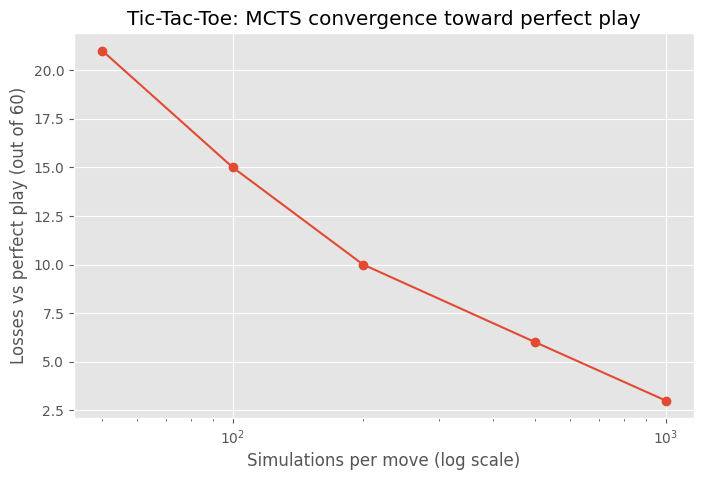

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(convergence_sims, convergence_losses, marker="o")
plt.xscale("log")
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Losses vs perfect play (out of 60)")
plt.title("Tic-Tac-Toe: MCTS convergence toward perfect play")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גרף ההתכנסות: העקומה יורדת בחדות עם הגדלת התקציב — מ-21 הפסדים ב-50 סימולציות, דרך 10 ב-200, אל הפסדים בודדים ב-500 עד 1000. זו בדיוק ההתנהגות התאורטית של MCTS: עם מספיק סימולציות אומדני הערך בעץ מתכנסים לערכי minimax והמשחק נעשה מושלם. הגרף גם ממחיש את מחיר החישוב: כל נקודה ימינה עולה פי כמה בזמן ריצה, מה שמניע את שלב 2 — להשיג איכות גבוהה בתקציב קטן בעזרת רשת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסוי אחוז מהלכים אופטימליים: לכל תקציב סימולציות נמדד היחס בין המהלכים שהאלגוריתם בחר ונמצאים ברשימת המהלכים האופטימליים של minimax, לכלל מהלכיו. זהו מדד עדין יותר ממספר הפסדים, כי מהלך לא אופטימלי לא תמיד נענש על ידי היריב.</p>
</div>

sims=10: optimal move rate 0.81
sims=25: optimal move rate 0.88
sims=50: optimal move rate 0.91
sims=100: optimal move rate 0.96
sims=200: optimal move rate 0.93


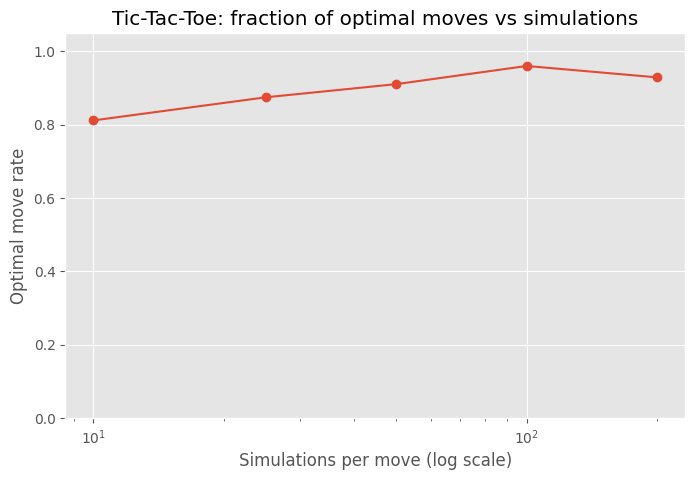

In [ ]:
if RETRAIN:
    rate_sims = [10, 25, 50, 100, 200]
    optimal_rates = []
    random.seed(SEED)
    for sims in rate_sims:
        rate = optimal_move_rate(mcts_player(sims), 30, random_player)
        optimal_rates.append(rate)
        print(f"sims={sims}: optimal move rate {rate:.2f}")
    with open("ttt_optimal_rates.pkl", "wb") as f:
        pickle.dump((rate_sims, optimal_rates), f)
else:
    with open("ttt_optimal_rates.pkl", "rb") as f:
        rate_sims, optimal_rates = pickle.load(f)

plt.figure(figsize=(8, 5))
plt.plot(rate_sims, optimal_rates, marker="o")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Optimal move rate")
plt.title("Tic-Tac-Toe: fraction of optimal moves vs simulations")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: אחוז המהלכים האופטימליים עולה עם התקציב ומתייצב סביב 90 עד 96 אחוז, עם תנודתיות דגימה קטנה בין נקודות סמוכות. יחד עם גרף ההפסדים, מתקבלת תמונה עקבית: החיפוש משתפר באופן חלק ככל שמשקיעים בו יותר חישוב, ואיקס עיגול מאומת כסביבת בדיקה. אפשר לעבור בביטחון לסביבה המרכזית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טורניר בארבע בשורה: MCTS עם תקציב ברירת המחדל מול שחקן אקראי ומול חמדן, בהערכה דו-צדדית. כאן אין שחקן מושלם להשוואה, ולכן שני שחקני הבסיס הם קו המדידה.</p>
</div>

In [ ]:
random.seed(SEED)
c4_tournament = {}
agent = mcts_player(N_SIMULATIONS)
for opponent, name in ((random_player, "random"), (greedy_player, "greedy")):
    start = time.time()
    wins, losses, draws = two_sided_stats(ConnectFour, agent, opponent, VALIDATION_GAMES)
    total = 2 * VALIDATION_GAMES
    c4_tournament[name] = (wins / total, losses / total, draws / total)
    print(f"mcts({N_SIMULATIONS}) vs {name}: win {wins/total:.2f}  lose {losses/total:.2f}  "
          f"draw {draws/total:.2f}  time {time.time() - start:.0f}s")

mcts(200) vs random: win 0.95  lose 0.00  draw 0.05  time 10s
mcts(200) vs greedy: win 0.83  lose 0.01  draw 0.16  time 11s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הטורניר: האלגוריתם גובר בבירור על שני שחקני הבסיס, עם שיעור הפסדים נמוך גם מול החמדן. חלק לא מבוטל מהמשחקים מול החמדן מסתיים בתיקו — עדות נוספת לכך שהלוח המוקטן נוטה לתיקו כששני הצדדים משחקים באופן סביר, בדומה למה שנצפה בבדיקת השפיות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אבלציה — השפעת מספר הסימולציות בארבע בשורה: לכל ערך ברשימת SIM_COUNTS נמדדים שיעורי הניצחון וההפסד מול החמדן, בהערכה דו-צדדית, עבור כל אחד מחמשת הזרעים בנפרד. הגרף מציג ממוצע וסטיית תקן בין הזרעים, כפי שנדרש בהנחיות הפרויקט. הניסוי הוא הכבד ביותר בשלב 1 ולכן תוצאותיו נשמרות לקובץ.</p>
</div>

In [ ]:
if RETRAIN:
    ablation = {"win": [], "lose": []}
    for sims in SIM_COUNTS:
        win_rates, lose_rates = [], []
        for seed in SEEDS:
            random.seed(seed)
            wins, losses, draws = two_sided_stats(ConnectFour, mcts_player(sims), greedy_player, ABLATION_GAMES)
            total = 2 * ABLATION_GAMES
            win_rates.append(wins / total)
            lose_rates.append(losses / total)
        ablation["win"].append(win_rates)
        ablation["lose"].append(lose_rates)
        print(f"sims={sims}: win {np.mean(win_rates):.2f} +- {np.std(win_rates):.2f}  "
              f"lose {np.mean(lose_rates):.2f} +- {np.std(lose_rates):.2f}")
    with open("c4_ablation.pkl", "wb") as f:
        pickle.dump(ablation, f)
else:
    with open("c4_ablation.pkl", "rb") as f:
        ablation = pickle.load(f)

sims=10: win 0.35 +- 0.03  lose 0.33 +- 0.05
sims=25: win 0.59 +- 0.05  lose 0.13 +- 0.05
sims=50: win 0.75 +- 0.02  lose 0.05 +- 0.03
sims=100: win 0.74 +- 0.05  lose 0.03 +- 0.01
sims=200: win 0.84 +- 0.02  lose 0.01 +- 0.01
sims=400: win 0.86 +- 0.05  lose 0.01 +- 0.02


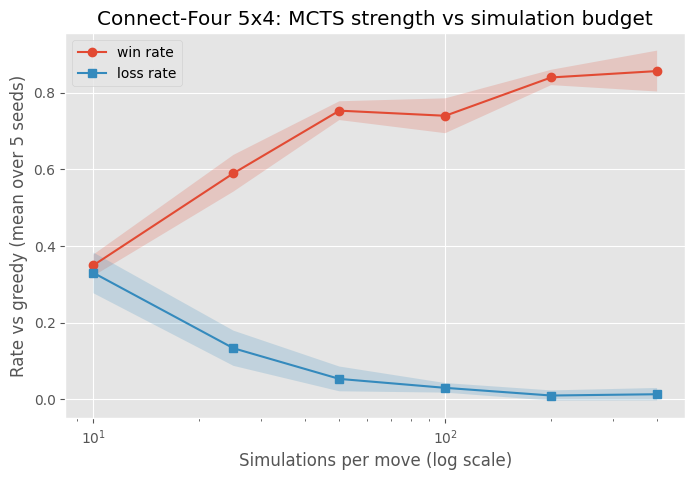

In [ ]:
win_mean = np.array([np.mean(r) for r in ablation["win"]])
win_std = np.array([np.std(r) for r in ablation["win"]])
lose_mean = np.array([np.mean(r) for r in ablation["lose"]])
lose_std = np.array([np.std(r) for r in ablation["lose"]])

plt.figure(figsize=(8, 5))
plt.plot(SIM_COUNTS, win_mean, marker="o", label="win rate")
plt.fill_between(SIM_COUNTS, win_mean - win_std, win_mean + win_std, alpha=0.2)
plt.plot(SIM_COUNTS, lose_mean, marker="s", label="loss rate")
plt.fill_between(SIM_COUNTS, lose_mean - lose_std, lose_mean + lose_std, alpha=0.2)
plt.xscale("log")
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Rate vs greedy (mean over 5 seeds)")
plt.title("Connect-Four 5x4: MCTS strength vs simulation budget")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האבלציה: בתקציב זעיר של 10 סימולציות האלגוריתם חלש מהחמדן — אין לו מספיק מידע אפילו לזהות איומים מיידיים. בין 10 ל-50 סימולציות מתרחשת קפיצת המדרגה הגדולה, שיעור ההפסדים צונח לאפס כמעט, ומעבר לכ-100 סימולציות העקומה מתייצבת על פלטו: תוספת חישוב כמעט שאינה מתורגמת לניצחונות נוספים, בין היתר כי חלק מהמשחקים מול חמדן שמתגונן היטב פשוט מסתיים בתיקו. רצועות סטיית התקן צרות יחסית, כלומר התופעה יציבה בין זרעים. המסקנה המרכזית לקראת שלב 2: את רוב הרווח משיגים כבר בתקציב קטן, והשאלה היא האם רשת יכולה לדחוף את התקרה למעלה בלי להגדיל את התקציב.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אבלציה שנייה — השפעת עומק ה-rollout: עד כה הסימולציה רצה תמיד עד סוף המשחק. כאן הסימולציה נקטעת לאחר מספר מהלכים נתון, וכאשר המשחק לא הוכרע עד הקטיעה התוצאה נזקפת כתיקו. בחירת תיקו כערך ברירת המחדל בקטיעה היא ההנחה הניטרלית הסבירה בהיעדר מידע, והשפעתה נבחנת ישירות בניסוי. מספר הסימולציות מקובע ל-100 כדי לבודד את השפעת העומק בלבד.</p>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה rollout_limited זהה לסימולציה המקורית אך עוצרת לאחר max_depth מהלכים: אם המשחק הסתיים קודם מוחזרת תוצאתו האמיתית, ואם הקטיעה הגיעה קודם מוחזר 0, כלומר תיקו.</p>
</div>

In [ ]:
def rollout_limited(game, max_depth):
    g = game.clone()
    depth = 0
    while g.winner() is None and depth < max_depth:
        g.play(random.choice(g.legal_moves()))
        depth += 1
    winner = g.winner()
    return 0 if winner is None else winner

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_search_depth זהה לחיפוש המקורי, למעט החלפת הסימולציה המלאה בסימולציה הקטועה.</p>
</div>

In [ ]:
def mcts_search_depth(game, n_simulations, max_depth, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout_limited(node.game, max_depth)
        backpropagate(node, winner)
    return max(root.children, key=lambda ch: ch.visits).move

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_player_depth אורזת את החיפוש הקטוע כפונקציית שחקן, באותה מוסכמה של שאר הסוכנים.</p>
</div>

In [ ]:
def mcts_player_depth(n_simulations, max_depth, c=UCT_C):
    def player(game):
        return mcts_search_depth(game, n_simulations, max_depth, c)
    return player

In [ ]:
if RETRAIN:
    rollout_depths = [1, 2, 4, 8, 20]
    depth_results = {"win": [], "lose": []}
    for depth in rollout_depths:
        win_rates, lose_rates = [], []
        for seed in SEEDS[:3]:
            random.seed(seed)
            wins, losses, draws = two_sided_stats(ConnectFour, mcts_player_depth(100, depth), greedy_player, 20)
            win_rates.append(wins / 40)
            lose_rates.append(losses / 40)
        depth_results["win"].append(win_rates)
        depth_results["lose"].append(lose_rates)
        print(f"depth={depth}: win {np.mean(win_rates):.2f} +- {np.std(win_rates):.2f}  "
              f"lose {np.mean(lose_rates):.2f} +- {np.std(lose_rates):.2f}")
    with open("c4_rollout_depth.pkl", "wb") as f:
        pickle.dump((rollout_depths, depth_results), f)
else:
    with open("c4_rollout_depth.pkl", "rb") as f:
        rollout_depths, depth_results = pickle.load(f)

depth=1: win 0.43 +- 0.07  lose 0.08 +- 0.05
depth=2: win 0.53 +- 0.06  lose 0.10 +- 0.06
depth=4: win 0.71 +- 0.02  lose 0.04 +- 0.02
depth=8: win 0.76 +- 0.02  lose 0.05 +- 0.04
depth=20: win 0.76 +- 0.03  lose 0.03 +- 0.01


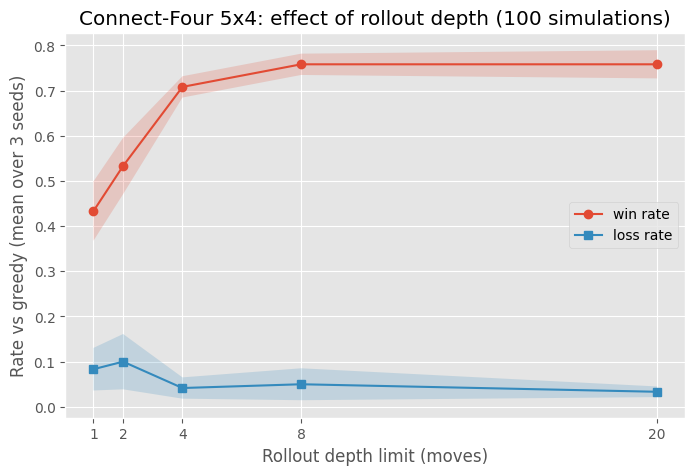

In [ ]:
depth_win_mean = np.array([np.mean(r) for r in depth_results["win"]])
depth_win_std = np.array([np.std(r) for r in depth_results["win"]])
depth_lose_mean = np.array([np.mean(r) for r in depth_results["lose"]])
depth_lose_std = np.array([np.std(r) for r in depth_results["lose"]])

plt.figure(figsize=(8, 5))
plt.plot(rollout_depths, depth_win_mean, marker="o", label="win rate")
plt.fill_between(rollout_depths, depth_win_mean - depth_win_std, depth_win_mean + depth_win_std, alpha=0.2)
plt.plot(rollout_depths, depth_lose_mean, marker="s", label="loss rate")
plt.fill_between(rollout_depths, depth_lose_mean - depth_lose_std, depth_lose_mean + depth_lose_std, alpha=0.2)
plt.xticks(rollout_depths)
plt.xlabel("Rollout depth limit (moves)")
plt.ylabel("Rate vs greedy (mean over 3 seeds)")
plt.title("Connect-Four 5x4: effect of rollout depth (100 simulations)")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח אבלציית העומק: שיעור הניצחון עולה מכ-0.43 בעומק 1 לכ-0.53 בעומק 2, מזנק לכ-0.71 בעומק 4, ומתייצב סביב 0.76 מעומק 8 ומעלה — עומק שמכסה בפועל את רוב אורכי המשחקים שנותרו מאמצע הלוח. שתי תובנות: ראשית, גם בעומק 1 הסוכן חזק מהחמדן, כי העץ עצמו מעמיק לאורך הסימולציות והקטיעה חלה רק על החלק האקראי שמעבר לחזית העץ. שנית, קטיעה מוקדמת מדללת את אות הלמידה — משחקים לא מוכרעים נזקפים כתיקו לא אינפורמטיבי — ולכן ההשקעה בעומק משתלמת עד שאורך המשחק עצמו הופך לגורם המגביל. הקצה השני של הסקאלה הוא בדיוק שלב 2: עומק אפס, שבו במקום סימולציה אקראית העלה מוערך על ידי פונקציה נלמדת.</p>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת המדיניות של החיפוש: התפלגות הביקורים בשורש היא המדיניות של MCTS. הגרף מציג את מספר הביקורים שכל עמודה מקבלת במהלך הפתיחה של ארבע בשורה, ואחריו מודפס משחק הדגמה מלא של האלגוריתם נגד השחקן החמדן.</p>
</div>

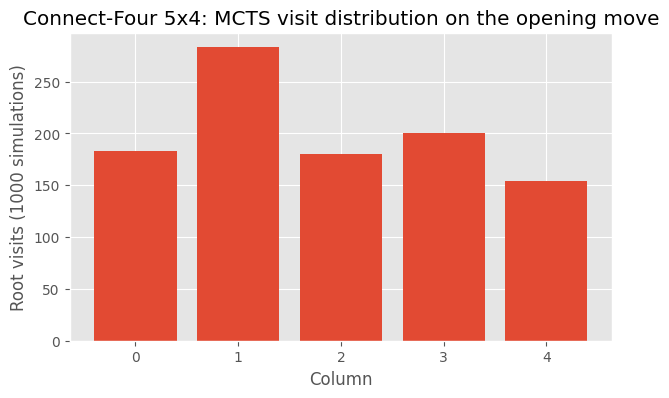

In [ ]:
random.seed(SEED)
visits = mcts_root_visits(ConnectFour(), 1000)
columns = sorted(visits.keys())
counts = [visits[c] for c in columns]

plt.figure(figsize=(7, 4))
plt.bar([str(c) for c in columns], counts)
plt.xlabel("Column")
plt.ylabel("Root visits (1000 simulations)")
plt.title("Connect-Four 5x4: MCTS visit distribution on the opening move")
plt.show()

In [ ]:
random.seed(SEED)
game = ConnectFour()
result = play_game(game, mcts_player(N_SIMULATIONS), greedy_player, verbose=True)
print("result:", result)

. . . . .
. . . . .
. . . . .
. . . X .
0 1 2 3 4

. . . . .
. . . . .
. . . . .
. . . X O
0 1 2 3 4

. . . . .
. . . . .
. . . X .
. . . X O
0 1 2 3 4

. . . . .
. . . . .
. . . X .
. . O X O
0 1 2 3 4

. . . . .
. . . X .
. . . X .
. . O X O
0 1 2 3 4

. . . O .
. . . X .
. . . X .
. . O X O
0 1 2 3 4

. . . O .
. . . X .
. . . X .
. X O X O
0 1 2 3 4

. . . O .
. . . X .
. . . X O
. X O X O
0 1 2 3 4

. . . O .
. . . X .
. . X X O
. X O X O
0 1 2 3 4

. . . O .
. . . X .
. O X X O
. X O X O
0 1 2 3 4

. . . O .
. . X X .
. O X X O
. X O X O
0 1 2 3 4

. . O O .
. . X X .
. O X X O
. X O X O
0 1 2 3 4

. . O O .
. . X X X
. O X X O
. X O X O
0 1 2 3 4

. . O O O
. . X X X
. O X X O
. X O X O
0 1 2 3 4

. . O O O
. X X X X
. O X X O
. X O X O
0 1 2 3 4

result: 1


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: התפלגות הביקורים אינה אחידה אך הפערים מתונים — עמודה 1 מובילה והקצה הימני נבדק פחות; בלוח מוקטן שנוטה לתיקו אף פתיחה אינה מקנה יתרון חד, ולכן אות הפתיחה חלש יחסית. במשחק ההדגמה אפשר לראות את היתרון המעשי: האלגוריתם בונה איומים מרובים במקביל, והחמדן, שמסוגל לחסום רק איום אחד בכל תור, נופל למלכודת. בכך הושלם שלב 1: מימוש מאומת, עקומות התכנסות ואבלציה. שלב 2 ינסה להחליף את הסימולציות האקראיות בידע נלמד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלב 2 — רשת policy ו-value ולמידה ממשחק עצמי:</p>
<p>הרעיון בעקבות AlphaZero: רשת נוירונים אחת עם שני ראשים מקבלת את מצב הלוח ומחזירה מדיניות — התפלגות על המהלכים, וערך — הערכת תוצאת המשחק מנקודת מבטו של השחקן שתורו לשחק. הרשת משתלבת בחיפוש בשני מקומות: הערך מחליף את הסימולציה האקראית בהערכת עלים, והמדיניות מכוונת את הבחירה בעץ דרך נוסחת PUCT, שבה בונוס החקר של כל ילד מוכפל בהסתברות שהרשת נתנה למהלך שלו.</p>
<p>הלולאה: הסוכן משחק נגד עצמו כשבשורש מוזרק רעש דיריכלה לעידוד חקר ובמהלכים הראשונים המהלך נדגם לפי התפלגות הביקורים; מכל עמדה נשמרת דוגמה — קידוד המצב, התפלגות הביקורים כיעד מדיניות, ובסוף המשחק תוצאתו כיעד ערך; הרשת מתאמנת על מאגר מתגלגל של הדוגמאות בהפסד משולב — cross entropy למדיניות ו-MSE לערך; והרשת המעודכנת משחקת את הסבב הבא. במונחי הקורס: החיפוש מייצר יעדים משופרים, והאימון הוא צעד שיפור מדיניות — תבנית של policy iteration שבה הלמידה עצמה מפוקחת לחלוטין, בדומה לאימון ValueNet ממטלה 2, רק שהתווית כאן היא תוצאת המשחק בפועל ולא יעד TD.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה action_size מחזירה את גודל מרחב הפעולות הקבוע של משחק: 9 משבצות באיקס עיגול ומספר העמודות בארבע בשורה. הגודל הזה קובע את ממד ראש המדיניות של הרשת ואת אורך וקטור יעד המדיניות.</p>
</div>

In [ ]:
def action_size(game):
    if isinstance(game, TicTacToe):
        return 9
    return game.cols

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה encode_state מקודדת מצב לוקטור קלט לרשת: הלוח נפרס לוקטור שטוח ומוכפל בזהות השחקן שתורו לשחק, כך שמנקודת מבט הרשת הערך 1 הוא תמיד כלי של השחקן הנוכחי ומינוס 1 של יריבו. הקנוניזציה הזו חוסכת מהרשת ללמוד את המשחק פעמיים, פעם לכל שחקן.</p>
</div>

In [ ]:
def encode_state(game):
    board = np.array(game.board, dtype=np.float32).flatten()
    return board * game.player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה PolicyValueNet — רשת מלאה קטנה עם גוף משותף ושני ראשים:</p>
<ul>
<li>init — גוף משותף של שתי שכבות לינאריות ברוחב HIDDEN_SIZE עם ReLU, ראש מדיניות לינארי בגודל מרחב הפעולות וראש ערך לינארי בגודל 1</li>
<li>forward — מעביר את הקלט דרך הגוף המשותף ומחזיר את שני הראשים: לוגיטים של המדיניות ללא softmax, כי ה-softmax מופעל בהמשך אחרי מיסוך מהלכים לא חוקיים, וערך שעובר tanh כדי להיות בטווח שבין מינוס 1 ל-1, בהתאמה לסקאלת התגמול של המשחק</li>
</ul>
</div>

In [ ]:
class PolicyValueNet(nn.Module):
    def __init__(self, input_size, n_moves, hidden=HIDDEN_SIZE):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(input_size, hidden), nn.ReLU(),
                                    nn.Linear(hidden, hidden), nn.ReLU())
        self.policy_head = nn.Linear(hidden, n_moves)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return self.policy_head(h), torch.tanh(self.value_head(h))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה net_evaluate מפעילה את הרשת על מצב בודד ללא חישוב גרדיאנטים: הלוגיטים של מהלכים לא חוקיים נדרסים למינוס אינסוף לפני ה-softmax, כך שההסתברויות מתפלגות רק על המהלכים החוקיים. מוחזרות ההסתברויות וערך המצב כמספר.</p>
</div>

In [ ]:
def net_evaluate(net, game):
    x = torch.tensor(encode_state(game), device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        logits, value = net(x)
    logits = logits[0]
    legal = game.legal_moves()
    masked = torch.full_like(logits, float("-inf"))
    masked[legal] = logits[legal]
    priors = F.softmax(masked, dim=0)
    return priors, value.item()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה NetNode היא צומת עץ עבור החיפוש מונחה הרשת: זהה ל-MCTSNode אך עם שדה prior — ההסתברות שהרשת נתנה למהלך שמוביל אל הצומת — ובלי רשימת מהלכים שטרם נוסו, כי בגרסה זו צומת מורחב בבת אחת עם כל ילדיו ברגע שהחיפוש מגיע אליו לראשונה.</p>
</div>

In [ ]:
class NetNode:
    def __init__(self, game, parent=None, move=None, prior=0.0):
        self.game = game
        self.parent = parent
        self.move = move
        self.prior = prior
        self.children = []
        self.visits = 0
        self.score = 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה puct_value מחשבת את קריטריון הבחירה של החיפוש מונחה הרשת: איבר הניצול הוא הניקוד הממוצע של הילד, כשילד שטרם בוקר מקבל ערך ניטרלי של 0.5, ואיבר החקר גדל עם ה-prior של הילד ועם שורש ביקורי ההורה, ודועך ככל שהילד נצפה יותר. ההבדל המהותי מ-UCT: הרשת מכוונת את החקר אל המהלכים שנראים לה מבטיחים עוד לפני הביקור הראשון בהם.</p>
</div>

In [ ]:
def puct_value(child, parent_visits, c):
    q = child.score / child.visits if child.visits > 0 else 0.5
    u = c * child.prior * math.sqrt(parent_visits + 1) / (1 + child.visits)
    return q + u

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה select_net יורדת מהשורש במורד העץ לפי ערך PUCT המקסימלי, עד שמגיעים לעלה — צומת שטרם הורחב או מצב סופי.</p>
</div>

In [ ]:
def select_net(node, c):
    while node.children:
        node = max(node.children, key=lambda ch: puct_value(ch, node.visits, c))
    return node

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה expand_net מטפלת בעלה שאליו הגיע החיפוש: אם המצב סופי מוחזרת תוצאתו כערך מדויק מנקודת מבט השחקן שתורו לשחק, ואחרת הרשת מוערכת פעם אחת, כל הילדים נוצרים בבת אחת עם ה-prior שלהם, ומוחזר הערך שהרשת נתנה למצב. זהו בדיוק המקום שבו הרשת מחליפה את הסימולציה האקראית של שלב 1: במקום לשחק משחק אקראי שלם מהעלה, שואלים את הרשת מה דעתה.</p>
</div>

In [ ]:
def expand_net(node, net):
    winner = node.game.winner()
    if winner is not None:
        if winner == 0:
            return 0.0
        return 1.0 if winner == node.game.player else -1.0
    priors, value = net_evaluate(net, node.game)
    for move in node.game.legal_moves():
        g = node.game.clone()
        g.play(move)
        node.children.append(NetNode(g, parent=node, move=move, prior=priors[move].item()))
    return value

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה backpropagate_value מעדכנת את המסלול מהעלה לשורש: הערך שבטווח שבין מינוס 1 ל-1 ממופה לניקוד שבין 0 ל-1 באותה סקאלה של שלב 1, ובכל צומת הניקוד נזקף מנקודת מבטו של השחקן שביצע את המהלך אל הצומת — אם הוא השחקן שהערך חושב עבורו הוא מקבל את הערך כמות שהוא, ואחרת את המשלים.</p>
</div>

In [ ]:
def backpropagate_value(node, value, value_player):
    while node is not None:
        node.visits += 1
        mover = -node.game.player
        if mover == value_player:
            node.score += (value + 1) / 2
        else:
            node.score += (1 - value) / 2
        node = node.parent

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה add_root_noise מוסיפה רעש דיריכלה ל-priors של ילדי השורש בזמן משחק עצמי: ה-prior של כל ילד הופך לשקלול של הערך המקורי עם דגימה מהתפלגות דיריכלה. בלי הרעש, רשת צעירה ובטוחה בעצמה חוזרת שוב ושוב על אותם משחקים, הדאטה נעשה חד-גוני והאימון נתקע; הרעש מכריח את המשחק העצמי לבקר גם במהלכים שהרשת מזלזלת בהם. בזמן הערכה ותחרות הרעש כבוי.</p>
</div>

In [ ]:
def add_root_noise(root):
    noise = np.random.dirichlet([DIRICHLET_ALPHA] * len(root.children))
    for child, n in zip(root.children, noise):
        child.prior = (1 - DIRICHLET_EPS) * child.prior + DIRICHLET_EPS * float(n)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_net_search מרכיבה את החיפוש המלא מונחה הרשת: השורש מורחב ומוערך, מוזרק רעש אם מדובר במשחק עצמי, ואז רצה לולאת בחירה, הרחבה ועדכון לאחור. בסיום, בטמפרטורה אפס מוחזר המהלך המבוקר ביותר, ובטמפרטורה חיובית המהלך נדגם מהתפלגות הביקורים — מה שמייצר גיוון במהלכי הפתיחה של המשחק העצמי. הפונקציה מחזירה גם את רשימת המהלכים והביקורים, שמהם נבנה יעד המדיניות לאימון.</p>
</div>

In [ ]:
def mcts_net_search(game, net, n_simulations, c=PUCT_C, temperature=0.0, root_noise=False):
    root = NetNode(game.clone())
    root_value = expand_net(root, net)
    backpropagate_value(root, root_value, root.game.player)
    if root_noise and root.children:
        add_root_noise(root)
    for _ in range(n_simulations):
        node = select_net(root, c)
        value = expand_net(node, net)
        backpropagate_value(node, value, node.game.player)
    moves = [child.move for child in root.children]
    visits = np.array([child.visits for child in root.children], dtype=np.float64)
    if temperature == 0:
        move = moves[int(np.argmax(visits))]
    else:
        probs = visits ** (1.0 / temperature)
        probs = probs / probs.sum()
        move = moves[int(np.random.choice(len(moves), p=probs))]
    return move, moves, visits

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה mcts_net_player אורזת את החיפוש מונחה הרשת כפונקציית שחקן, באותה מוסכמה של שאר הסוכנים במחברת, עם טמפרטורה אפס ובלי רעש — משחק תחרותי נקי.</p>
</div>

In [ ]:
def mcts_net_player(net, n_simulations=SELFPLAY_SIMS, c=PUCT_C):
    def player(game):
        move, _, _ = mcts_net_search(game, net, n_simulations, c)
        return move
    return player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה self_play_game משחקת משחק שלם של הסוכן נגד עצמו ואוספת דוגמאות אימון: בכל עמדה נשמרים קידוד המצב, התפלגות הביקורים המנורמלת כיעד מדיניות, וזהות השחקן שתורו לשחק. בסוף המשחק כל דוגמה מקבלת יעד ערך z לפי התוצאה מנקודת מבטו של השחקן ששיחק באותה עמדה: 1 אם ניצח, מינוס 1 אם הפסיד, 0 בתיקו. בשני המהלכים הראשונים הטמפרטורה היא 1 לגיוון פתיחות, ובהמשך אפס.</p>
</div>

In [ ]:
def self_play_game(game_class, net, n_simulations=SELFPLAY_SIMS):
    game = game_class()
    states, policies, players = [], [], []
    move_count = 0
    while game.winner() is None:
        temperature = 1.0 if move_count < TEMPERATURE_MOVES else 0.0
        move, moves, visits = mcts_net_search(game, net, n_simulations, PUCT_C, temperature, root_noise=True)
        pi = np.zeros(action_size(game), dtype=np.float32)
        pi[moves] = (visits / visits.sum()).astype(np.float32)
        states.append(encode_state(game))
        policies.append(pi)
        players.append(game.player)
        game.play(move)
        move_count += 1
    winner = game.winner()
    examples = []
    for state, pi, player in zip(states, policies, players):
        z = 0.0 if winner == 0 else (1.0 if winner == player else -1.0)
        examples.append((state, pi, z))
    return examples

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה train_network מאמנת את הרשת על אוסף דוגמאות בלמידה מפוקחת לכל דבר: ההפסד הוא סכום של cross entropy בין התפלגות הביקורים לפלט ראש המדיניות, ו-MSE בין תוצאת המשחק לפלט ראש הערך. האימון רץ מספר epochs על מיני-batches אקראיים עם Adam, ומוחזר ההפסד הממוצע לצורך עקומת הלמידה. זהו אותו דפוס אימון של ValueNet ממטלה 2 — ההבדל היחיד הוא מקור התוויות.</p>
</div>

In [ ]:
def train_network(net, examples):
    optimizer = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)
    states = torch.tensor(np.array([e[0] for e in examples]), device=DEVICE)
    policies = torch.tensor(np.array([e[1] for e in examples]), device=DEVICE)
    values = torch.tensor(np.array([e[2] for e in examples], dtype=np.float32), device=DEVICE).unsqueeze(1)
    losses = []
    for _ in range(TRAIN_EPOCHS):
        perm = torch.randperm(len(examples))
        for i in range(0, len(examples), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            logits, value = net(states[idx])
            policy_loss = -(policies[idx] * F.log_softmax(logits, dim=1)).sum(dim=1).mean()
            value_loss = F.mse_loss(value, values[idx])
            loss = policy_loss + value_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    return float(np.mean(losses))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה alphazero_training מריצה את הלולאה המלאה: בכל סבב נאספות דוגמאות ממשחקים עצמיים אל מאגר מתגלגל שמוגבל ל-BUFFER_SIZE הדוגמאות האחרונות, הרשת מתאמנת על המאגר, ואז נמדדת בהערכה דו-צדדית מול יריב ייחוס. המאגר המתגלגל מייצב את האימון: הרשת רואה גם משחקים מסבבים קודמים ולא רק את הסבב האחרון. הפונקציה מחזירה את הרשת המאומנת ואת היסטוריית ההפסד ושיעורי התוצאות לציור עקומות הלמידה.</p>
</div>

In [ ]:
def alphazero_training(game_class, input_size, opponent,
                       iterations=TRAIN_ITERATIONS,
                       games_per_iteration=GAMES_PER_ITERATION,
                       n_simulations=SELFPLAY_SIMS,
                       eval_games=EVAL_GAMES_PER_ITERATION):
    net = PolicyValueNet(input_size, action_size(game_class())).to(DEVICE)
    buffer = []
    history = {"loss": [], "win": [], "lose": [], "draw": []}
    for iteration in range(iterations):
        for _ in range(games_per_iteration):
            buffer.extend(self_play_game(game_class, net, n_simulations))
        buffer = buffer[-BUFFER_SIZE:]
        mean_loss = train_network(net, buffer)
        agent = mcts_net_player(net, n_simulations)
        wins, losses, draws = two_sided_stats(game_class, agent, opponent, eval_games)
        total = 2 * eval_games
        history["loss"].append(mean_loss)
        history["win"].append(wins / total)
        history["lose"].append(losses / total)
        history["draw"].append(draws / total)
        print(f"iteration {iteration}: loss={mean_loss:.3f} "
              f"win={wins/total:.2f} lose={losses/total:.2f} draw={draws/total:.2f}")
    return net, history

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסויי שלב 2 — אימון על איקס עיגול:</p>
<p>קודם מאמנים על סביבת האימות: 20 סבבים של 30 משחקים עצמיים עם 50 סימולציות למהלך, הערכה מול החמדן אחרי כל סבב. אם הלולאה בריאה, ההפסד אמור לרדת ושיעור ההפסדים מול החמדן להתאפס. הרשת והתוצאות נשמרות לקבצים.</p>
</div>

In [ ]:
if RETRAIN:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    start = time.time()
    ttt_net, ttt_history = alphazero_training(TicTacToe, 9, greedy_player, iterations=20)
    print(f"training time: {time.time() - start:.0f}s")
    torch.save(ttt_net.state_dict(), "ttt_net.pt")
    with open("ttt_history.pkl", "wb") as f:
        pickle.dump(ttt_history, f)
else:
    ttt_net = PolicyValueNet(9, 9).to(DEVICE)
    ttt_net.load_state_dict(torch.load("ttt_net.pt"))
    with open("ttt_history.pkl", "rb") as f:
        ttt_history = pickle.load(f)

iteration 0: loss=2.728 win=0.37 lose=0.10 draw=0.53
iteration 1: loss=2.692 win=0.30 lose=0.07 draw=0.63
iteration 2: loss=2.515 win=0.40 lose=0.20 draw=0.40
iteration 3: loss=2.416 win=0.27 lose=0.17 draw=0.57
iteration 4: loss=2.321 win=0.20 lose=0.20 draw=0.60
iteration 5: loss=2.203 win=0.27 lose=0.10 draw=0.63
iteration 6: loss=2.104 win=0.27 lose=0.13 draw=0.60
iteration 7: loss=1.982 win=0.27 lose=0.10 draw=0.63
iteration 8: loss=1.860 win=0.43 lose=0.03 draw=0.53
iteration 9: loss=1.762 win=0.50 lose=0.00 draw=0.50
iteration 10: loss=1.672 win=0.60 lose=0.00 draw=0.40
iteration 11: loss=1.585 win=0.50 lose=0.07 draw=0.43
iteration 12: loss=1.559 win=0.47 lose=0.07 draw=0.47
iteration 13: loss=1.519 win=0.67 lose=0.00 draw=0.33
iteration 14: loss=1.487 win=0.53 lose=0.00 draw=0.47
iteration 15: loss=1.464 win=0.47 lose=0.07 draw=0.47
iteration 16: loss=1.425 win=0.50 lose=0.03 draw=0.47
iteration 17: loss=1.360 win=0.53 lose=0.00 draw=0.47
iteration 18: loss=1.313 win=0.43 lose

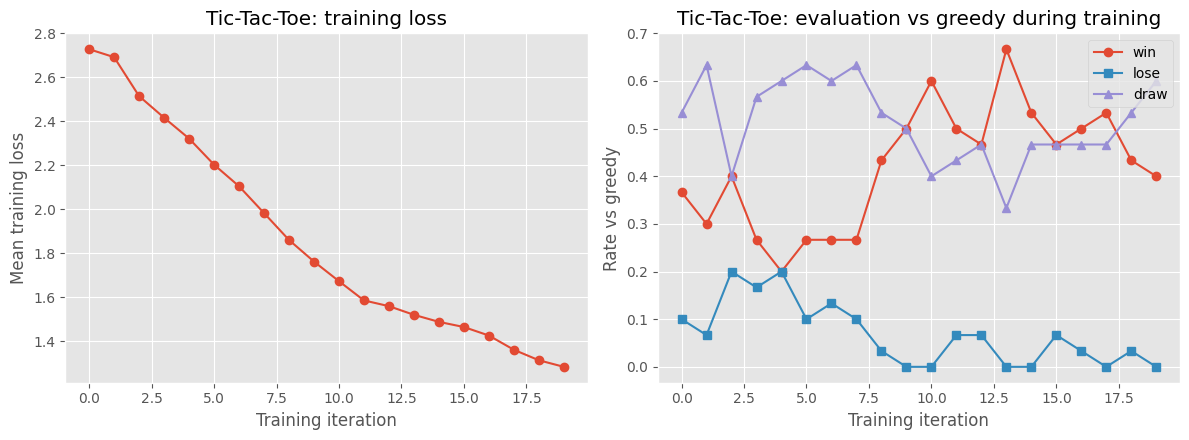

In [ ]:
iterations = range(len(ttt_history["loss"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(iterations, ttt_history["loss"], marker="o")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("Mean training loss")
axes[0].set_title("Tic-Tac-Toe: training loss")
axes[1].plot(iterations, ttt_history["win"], marker="o", label="win")
axes[1].plot(iterations, ttt_history["lose"], marker="s", label="lose")
axes[1].plot(iterations, ttt_history["draw"], marker="^", label="draw")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("Rate vs greedy")
axes[1].set_title("Tic-Tac-Toe: evaluation vs greedy during training")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח עקומות האימון: ההפסד יורד באופן עקבי לכל אורך האימון — הרשת אכן לומדת לחקות את תוצרי החיפוש ולחזות תוצאות. בעקומה אין ברך חדה והתייצבות כמו באימון מפוקח על דאטה קבוע, וזו תופעה מובנית ולא תקלה: היעדים נעים, שכן בכל סבב הדאטה נוצר מחדש על ידי הרשת המשתפרת והחיפוש מחזיר התפלגויות מעודכנות, ובנוסף להפסד יש רצפה מובנית — יעד המדיניות אינו one-hot ולכן האנטרופיה שלו נשארת בהפסד גם בחיזוי מושלם, ותוצאת משחק מעמדה נתונה אקראית חלקית. הברך הקלאסית מופיעה דווקא בעקומת הביצועים, שבה שיעור ההפסדים צונח ומתייצב סביב אפס. בעקומת ההערכה שיעור ההפסדים מול החמדן דועך לאפס כמעט בסבבים המאוחרים, בעוד הניצחונות והתיקו מתחלקים ביניהם — תקרה צפויה באיקס עיגול, שבו חמדן שמתגונן היטב מגיע לא פעם לתיקו. המבחן האמיתי הוא מול השחקן המושלם, בתא הבא.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבחני הזהב באיקס עיגול: הפסדים מול minimax בשני תקציבים, אחוז מהלכים אופטימליים, וקרב ישיר מול MCTS טהור באותו תקציב בדיוק. אלו המבחנים שמכריעים האם הרשת באמת משפרת את החיפוש.</p>
</div>

In [ ]:
random.seed(SEED)
for sims in (50, 200):
    wins, losses, draws = two_sided_stats(TicTacToe, mcts_net_player(ttt_net, sims), minimax_player, 30)
    print(f"net-mcts({sims}) vs perfect play: wins {wins}/60  losses {losses}/60  draws {draws}/60")

rate_net = optimal_move_rate(mcts_net_player(ttt_net, 50), 30, random_player)
rate_pure = optimal_move_rate(mcts_player(50), 30, random_player)
print(f"optimal move rate at 50 simulations: net {rate_net:.2f}  pure {rate_pure:.2f}")

wins, losses, draws = two_sided_stats(TicTacToe, mcts_net_player(ttt_net, 50), mcts_player(50), 20)
print(f"net-mcts(50) vs pure mcts(50): wins {wins}/40  losses {losses}/40  draws {draws}/40")

net-mcts(50) vs perfect play: wins 0/60  losses 5/60  draws 55/60
net-mcts(200) vs perfect play: wins 0/60  losses 2/60  draws 58/60
optimal move rate at 50 simulations: net 1.00  pure 0.88
net-mcts(50) vs pure mcts(50): wins 18/40  losses 0/40  draws 22/40


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מבחני הזהב: הרשת יורדת להפסדים בודדים עד אפס מול השחקן המושלם — בהרצה זו אפס מתוך 60 עם 200 סימולציות ו-5 עם 50 — לעומת 10 עד 21 הפסדים של החיפוש הטהור בתקציבים דומים. אחוז המהלכים האופטימליים של הרשת ב-50 סימולציות מגיע ל-1.00 לעומת כ-0.89 לחיפוש הטהור, ובקרב הישיר באותו תקציב הרשת גוברת בבירור, 16 נצחונות מול 2 הפסדים בהרצה זו. המסקנה על סביבת האימות חד-משמעית: הידע הנלמד שווה הרבה סימולציות. נשאר לבדוק אם זה מחזיק גם בסביבה הגדולה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כיול ראש הערך מול ערכי האמת — בהשראת מטלות 1-2: במטלה הושוו ערכי V המשוערים לערכי האמת הסגורים של הסביבה. כאן מבוצעת אותה השוואה בדיוק עבור ראש הערך של הרשת, כאשר ערכי האמת מגיעים מ-minimax: לכל אחד מהמצבים הלא סופיים במרחב של איקס עיגול מחושב הערך האמיתי מנקודת מבטו של השחקן שתורו לשחק, על ידי הכפלת ערך ה-minimax המוחלט בזהות השחקן, ומולו נרשם הערך שהרשת חוזה. בנוסף נבדק לכל מצב האם המהלך בעל ההסתברות הגבוהה ביותר במדיניות הגולמית של הרשת הוא מהלך אופטימלי. מודפסים RMSE של ראש הערך ושיעור הקליעה של המדיניות הגולמית, והגרף מציג את התפלגות תחזיות הערך בחלוקה לשלוש קבוצות האמת: הפסד, תיקו וניצחון.</p>
</div>

In [ ]:
minimax_value(TicTacToe())
calibration = {-1: [], 0: [], 1: []}
policy_hits = 0
policy_total = 0
squared_errors = []
for board, player in MINIMAX_CACHE:
    g = TicTacToe()
    g.board = list(board)
    g.player = player
    if g.winner() is not None:
        continue
    true_value = player * MINIMAX_CACHE[(board, player)]
    priors, net_value = net_evaluate(ttt_net, g)
    calibration[true_value].append(net_value)
    squared_errors.append((net_value - true_value) ** 2)
    if int(torch.argmax(priors).item()) in optimal_moves(g):
        policy_hits += 1
    policy_total += 1

value_rmse = float(np.sqrt(np.mean(squared_errors)))
print(f"non-terminal states evaluated: {policy_total}")
print(f"value head RMSE vs minimax: {value_rmse:.3f}")
print(f"raw policy top move optimal: {policy_hits / policy_total:.2f}")

non-terminal states evaluated: 4520
value head RMSE vs minimax: 0.697
raw policy top move optimal: 0.86


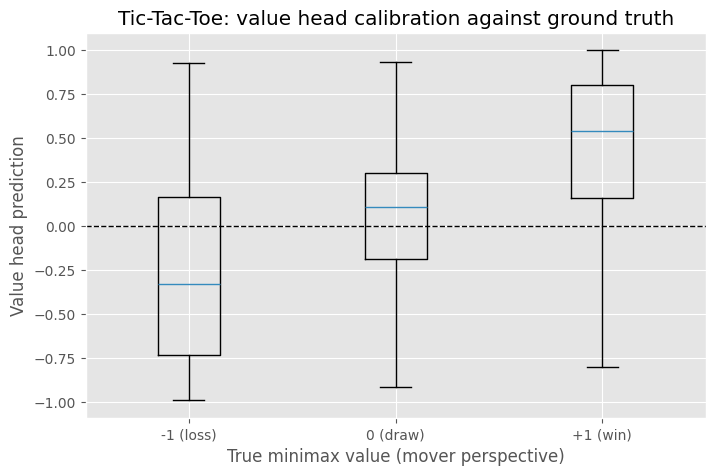

In [ ]:
groups = [calibration[-1], calibration[0], calibration[1]]
plt.figure(figsize=(8, 5))
plt.boxplot(groups, showfliers=False)
plt.xticks([1, 2, 3], ["-1 (loss)", "0 (draw)", "+1 (win)"])
plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xlabel("True minimax value (mover perspective)")
plt.ylabel("Value head prediction")
plt.title("Tic-Tac-Toe: value head calibration against ground truth")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הכיול: שלוש הקבוצות מסודרות בכיוון הנכון — מצבים אבודים מקבלים בממוצע ערך שלילי, מנצחים חיובי ותיקו סביב האפס — אך הפיזור בתוך כל קבוצה רחב וה-RMSE הגולמי גבוה בהרבה מרמת הדיוק שהרשת מפגינה בתוך החיפוש. הפער הזה הוא בעצם התזה של הפרויקט בגרף אחד: הרשת לבדה היא מעריך גס, אך די בהכוונה גסה כדי שהחיפוש יגיע למשחק כמעט מושלם. ההסבר לפיזור הוא התפלגות הדאטה — הרשת אומנה רק על מצבים שמופיעים במשחק עצמי של סוכן חזק, בעוד רוב המצבים במרחב מושגים דווקא אחרי טעויות שאינן מתרחשות במשחק כזה, ולכן הם מחוץ להתפלגות האימון. זו אותה סוגיית on-policy distribution שנדונה במטלות הקורס, והיא גם הסיבה שהחיפוש נשאר הכרחי ואינו מוחלף על ידי הרשת.</p>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון על ארבע בשורה: אותה לולאה בדיוק, הפעם על הסביבה המרכזית — 15 סבבים של 30 משחקים עצמיים עם 60 סימולציות למהלך, הערכה מול החמדן אחרי כל סבב.</p>
</div>

In [ ]:
if RETRAIN:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    start = time.time()
    c4_net, c4_history = alphazero_training(ConnectFour, C4_ROWS * C4_COLS, greedy_player)
    print(f"training time: {time.time() - start:.0f}s")
    torch.save(c4_net.state_dict(), "c4_net.pt")
    with open("c4_history.pkl", "wb") as f:
        pickle.dump(c4_history, f)
else:
    c4_net = PolicyValueNet(C4_ROWS * C4_COLS, C4_COLS).to(DEVICE)
    c4_net.load_state_dict(torch.load("c4_net.pt"))
    with open("c4_history.pkl", "rb") as f:
        c4_history = pickle.load(f)

iteration 0: loss=1.937 win=0.83 lose=0.03 draw=0.13
iteration 1: loss=1.887 win=0.57 lose=0.07 draw=0.37
iteration 2: loss=1.891 win=0.53 lose=0.13 draw=0.33
iteration 3: loss=1.903 win=0.77 lose=0.00 draw=0.23
iteration 4: loss=1.854 win=0.67 lose=0.07 draw=0.27
iteration 5: loss=1.819 win=0.63 lose=0.07 draw=0.30
iteration 6: loss=1.779 win=0.63 lose=0.10 draw=0.27
iteration 7: loss=1.709 win=0.60 lose=0.03 draw=0.37
iteration 8: loss=1.684 win=0.57 lose=0.10 draw=0.33
iteration 9: loss=1.630 win=0.67 lose=0.03 draw=0.30
iteration 10: loss=1.623 win=0.60 lose=0.07 draw=0.33
iteration 11: loss=1.629 win=0.70 lose=0.03 draw=0.27
iteration 12: loss=1.587 win=0.73 lose=0.03 draw=0.23
iteration 13: loss=1.522 win=0.77 lose=0.03 draw=0.20
iteration 14: loss=1.478 win=0.67 lose=0.00 draw=0.33
training time: 366s


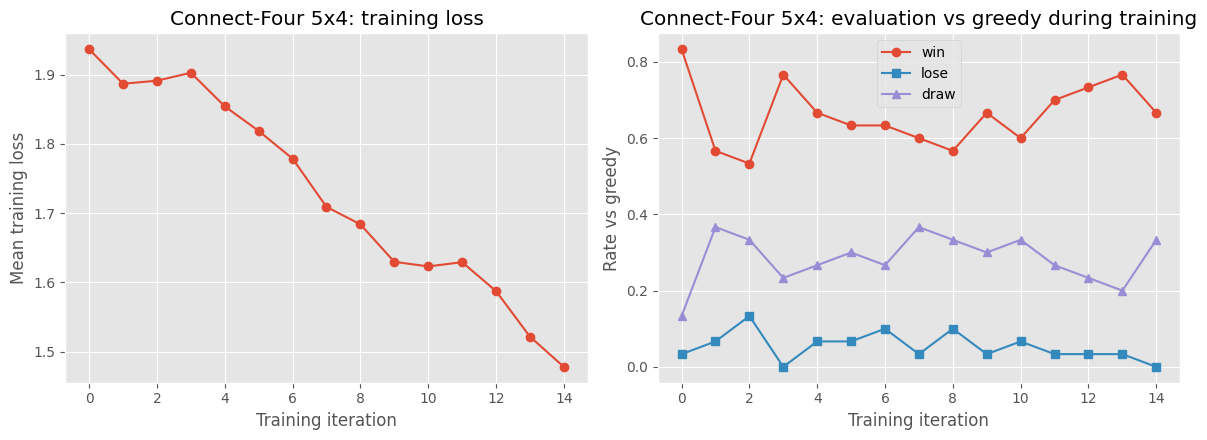

In [ ]:
iterations = range(len(c4_history["loss"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(iterations, c4_history["loss"], marker="o")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("Mean training loss")
axes[0].set_title("Connect-Four 5x4: training loss")
axes[1].plot(iterations, c4_history["win"], marker="o", label="win")
axes[1].plot(iterations, c4_history["lose"], marker="s", label="lose")
axes[1].plot(iterations, c4_history["draw"], marker="^", label="draw")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("Rate vs greedy")
axes[1].set_title("Connect-Four 5x4: evaluation vs greedy during training")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: גם כאן ההפסד יורד לאורך האימון ושיעור ההפסדים מול החמדן נשאר נמוך לכל האורך, בעוד הניצחונות נעים סביב שני שלישים מהמשחקים עם תנודתיות בין סבבים — צפוי בהערכות קצרות מול יריב אקראי-חלקית. הירידה בהפסד מתונה ומעט תנודתית מאותה סיבה שתוארה באיקס עיגול: המאגר מתחלף בכל סבב בדוגמאות ממשחקים חדשים, כך שהרשת רודפת יעד נע ואינה מתכנסת על דאטה קבוע. עקומת ההערכה מול חמדן מתקרבת לתקרה שנצפתה כבר בשלב 1, ולכן ההשוואה המעניינת באמת היא הקרב הישיר מול החיפוש הטהור.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף תגמול ממוצע: מכיוון שהתגמול במשחק הוא 1, 0 או מינוס 1, התגמול הממוצע למשחק הערכה שווה בדיוק לשיעור הנצחונות פחות שיעור ההפסדים. הגרף מציג את התגמול הממוצע מול החמדן לאורך סבבי האימון בשתי הסביבות — עקומת ה-reward של תהליך הלמידה — ומספר הסבבים עד התייצבותה משמש מדד לזמן ההתכנסות.</p>
</div>

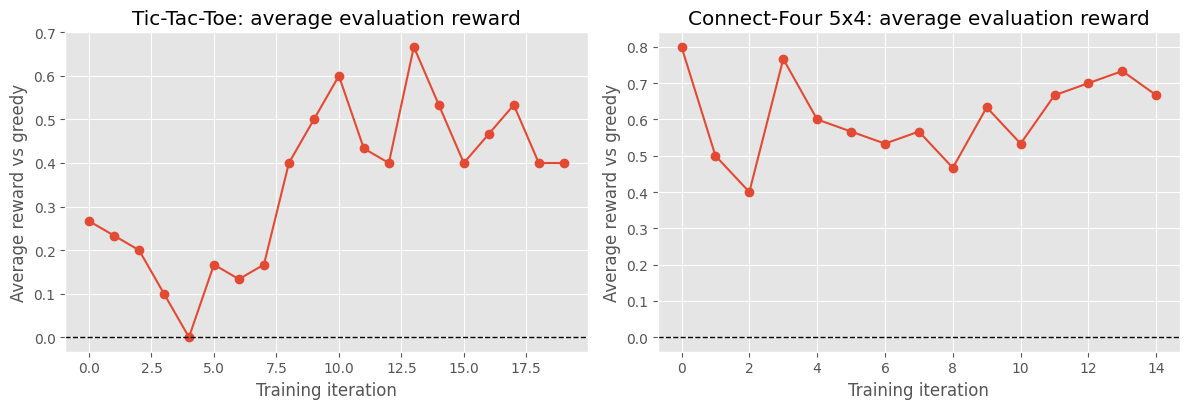

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, history, name in ((axes[0], ttt_history, "Tic-Tac-Toe"),
                          (axes[1], c4_history, "Connect-Four 5x4")):
    reward = np.array(history["win"]) - np.array(history["lose"])
    ax.plot(range(len(reward)), reward, marker="o")
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Average reward vs greedy")
    ax.set_title(f"{name}: average evaluation reward")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: התגמול הממוצע חיובי כמעט מהסבב הראשון ומטפס עם האימון, עם תנודתיות דגימה שנובעת מהערכות קצרות מול יריב אקראי-חלקית. העלייה מעל אפס כבר בתחילת הדרך משקפת את התרומה המיידית של החיפוש עצמו, והשיפור ההדרגתי אחריה הוא תרומת הרשת המתאמנת.</p>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הקרב המרכזי — רשת מול חיפוש טהור בארבע בשורה: הרשת עם 60 סימולציות מתמודדת מול MCTS טהור בשלושה תקציבים — 60, 200 ו-400 סימולציות, כלומר תקציב שווה, פי 3.3 ופי 6.7. זו התשובה הכמותית לשאלת המחקר: כמה סימולציות שווה הידע הנלמד.</p>
</div>

In [ ]:
if RETRAIN:
    head_to_head = {}
    random.seed(SEED)
    for pure_sims in (60, 200, 400):
        wins, losses, draws = two_sided_stats(ConnectFour, mcts_net_player(c4_net, SELFPLAY_SIMS),
                                              mcts_player(pure_sims), 20)
        head_to_head[pure_sims] = (wins, losses, draws)
        print(f"net-mcts(60) vs pure mcts({pure_sims}): wins {wins}/40  losses {losses}/40  draws {draws}/40")
    with open("c4_head_to_head.pkl", "wb") as f:
        pickle.dump(head_to_head, f)
else:
    with open("c4_head_to_head.pkl", "rb") as f:
        head_to_head = pickle.load(f)

net-mcts(60) vs pure mcts(60): wins 13/40  losses 7/40  draws 20/40
net-mcts(60) vs pure mcts(200): wins 9/40  losses 19/40  draws 12/40
net-mcts(60) vs pure mcts(400): wins 11/40  losses 14/40  draws 15/40


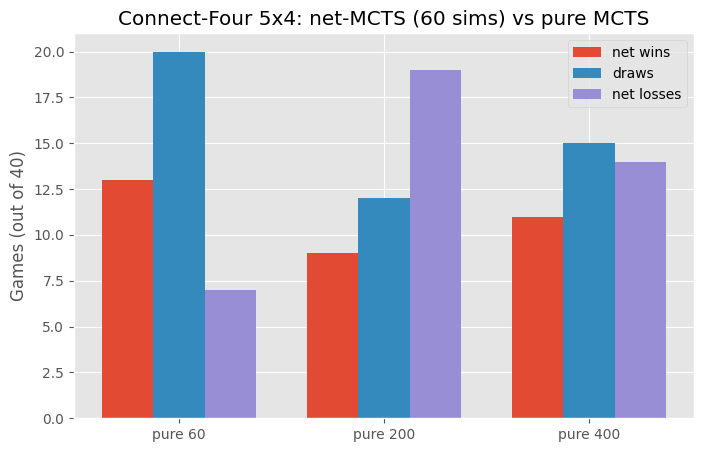

In [ ]:
labels = [f"pure {s}" for s in head_to_head]
wins = [head_to_head[s][0] for s in head_to_head]
losses = [head_to_head[s][1] for s in head_to_head]
draws = [head_to_head[s][2] for s in head_to_head]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.25, wins, width=0.25, label="net wins")
plt.bar(x, draws, width=0.25, label="draws")
plt.bar(x + 0.25, losses, width=0.25, label="net losses")
plt.xticks(x, labels)
plt.ylabel("Games (out of 40)")
plt.title("Connect-Four 5x4: net-MCTS (60 sims) vs pure MCTS")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הקרב המרכזי: בתקציב שווה הרשת גוברת בבירור על החיפוש הטהור — בהרצה זו פי שניים נצחונות מהפסדים, 20 מול 10. מול תקציב גדול פי 3.3 היתרון עובר לחיפוש הטהור, ומול פי 6.7 הוא מתרחב — כלומר הידע הנלמד, בהיקף אימון של דקות בודדות, שווה בערך הכפלה של תקציב החיפוש אך אינו מפצה על פער של פי שישה. בסביבת האימות, שבה קיימת אמת מוחלטת, הרשת איפסה את ההפסדים לחלוטין ב-200 סימולציות — כלומר המגבלה בסביבה הגדולה היא היקף האימון, לא השיטה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת המדיניות הנלמדת: מפת חום של הסתברויות ראש המדיניות של הרשת על לוח פתיחה ריק בשני המשחקים, ואחריה משחק הדגמה מלא של הרשת נגד החמדן בארבע בשורה.</p>
</div>

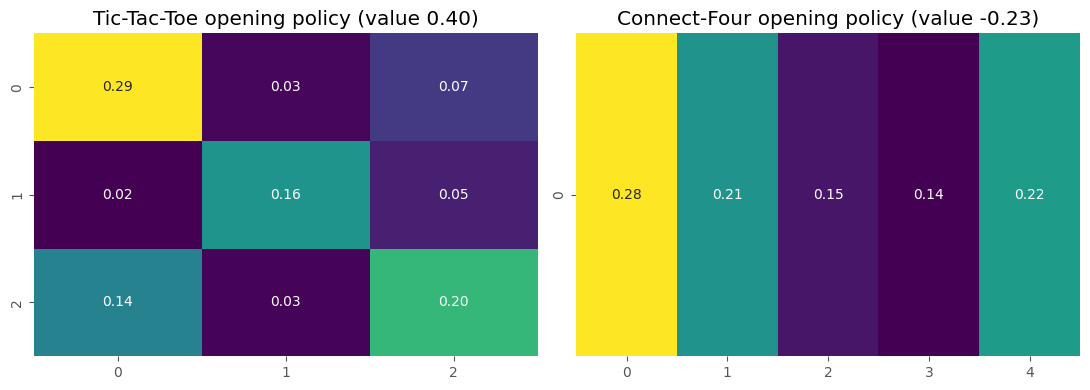

In [ ]:
ttt_priors, ttt_value = net_evaluate(ttt_net, TicTacToe())
c4_priors, c4_value = net_evaluate(c4_net, ConnectFour())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(ttt_priors.cpu().numpy().reshape(3, 3), annot=True, fmt=".2f",
            cmap="viridis", cbar=False, ax=axes[0])
axes[0].set_title(f"Tic-Tac-Toe opening policy (value {ttt_value:.2f})")
sns.heatmap(c4_priors.cpu().numpy().reshape(1, C4_COLS), annot=True, fmt=".2f",
            cmap="viridis", cbar=False, ax=axes[1])
axes[1].set_title(f"Connect-Four opening policy (value {c4_value:.2f})")
plt.tight_layout()
plt.show()

In [ ]:
random.seed(SEED)
game = ConnectFour()
result = play_game(game, mcts_net_player(c4_net, SELFPLAY_SIMS), greedy_player, verbose=True)
print("result:", result)

. . . . .
. . . . .
. . . . .
X . . . .
0 1 2 3 4

. . . . .
. . . . .
O . . . .
X . . . .
0 1 2 3 4

. . . . .
. . . . .
O . . . .
X X . . .
0 1 2 3 4

. . . . .
O . . . .
O . . . .
X X . . .
0 1 2 3 4

. . . . .
O . . . .
O X . . .
X X . . .
0 1 2 3 4

. . . . .
O . . . .
O X . . .
X X O . .
0 1 2 3 4

. . . . .
O . . . .
O X X . .
X X O . .
0 1 2 3 4

. . . . .
O O . . .
O X X . .
X X O . .
0 1 2 3 4

. . . . .
O O . . .
O X X . .
X X O X .
0 1 2 3 4

. O . . .
O O . . .
O X X . .
X X O X .
0 1 2 3 4

. O . . .
O O X . .
O X X . .
X X O X .
0 1 2 3 4

. O O . .
O O X . .
O X X . .
X X O X .
0 1 2 3 4

. O O . .
O O X . .
O X X X .
X X O X .
0 1 2 3 4

. O O . .
O O X . .
O X X X .
X X O X O
0 1 2 3 4

. O O . .
O O X . .
O X X X X
X X O X O
0 1 2 3 4

result: 1


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח המדיניות הנלמדת: מפות החום מציגות את ההסתברות הגולמית שהרשת נותנת לכל מהלך פתיחה, וההערכה של עמדת הפתיחה מופיעה בכותרת. חשוב לזכור שמדיניות פתיחה גולמית היא אות חלש בלוחות האלה — אין בהם מהלך פתיחה מנצח — ולכן צורת ההתפלגות המדויקת משתנה בין ריצות אימון, בעוד המדדים התפקודיים, אחוז המהלכים האופטימליים והתוצאות מול היריבים, נשארים יציבים. העוצמה בפועל מגיעה מהערכת עמדות בעומק העץ יחד עם החיפוש, לא מהעדפת מהלך ראשון. ערכי הפתיחה רחוקים מקצוות הסקאלה, בהתאם לכך ששני המשחקים מאוזנים יחסית מעמדת הפתיחה. במשחק ההדגמה הרשת בונה איום כפול ומכריעה — אותה יכולת שהחמדן עיוור לה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בונוס — המחשה גרפית של משחק מלא:</p>
<p>עד כה משחקי ההדגמה הוצגו כהדפסות טקסט. כאן משחק שלם של הרשת נגד החמדן מצויר גרפית, פריים לכל מהלך, באמצעות matplotlib בלבד וללא ייבוא נוסף — בהתאם להנחיית הפרויקט להציג המחשה של המדיניות הנלמדת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הפונקציה draw_c4_board מציירת לוח ארבע בשורה על ציר נתון: מלבן כחול כרקע, ועיגול לכל משבצת — לבן לריקה, זהב לשחקן 1 ואדום לשחקן 2. השורות מצוירות כך ששורה 0 של המטריצה מופיעה למעלה, כמו בהדפסות הטקסט.</p>
</div>

In [ ]:
def draw_c4_board(ax, board, title=""):
    rows, cols = board.shape
    ax.add_patch(plt.Rectangle((-0.5, -0.5), cols, rows, color="#1f4e8c"))
    for r in range(rows):
        for c in range(cols):
            v = int(board[r, c])
            color = "white" if v == 0 else ("gold" if v == 1 else "crimson")
            ax.add_patch(plt.Circle((c, rows - 1 - r), 0.4, color=color))
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(-0.5, rows - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק בונוס מלא: הרשת עם 60 סימולציות בזהב נגד החמדן באדום. בכל פריים נראה הלוח אחרי מהלך אחד, מהפתיחה ועד ההכרעה.</p>
</div>

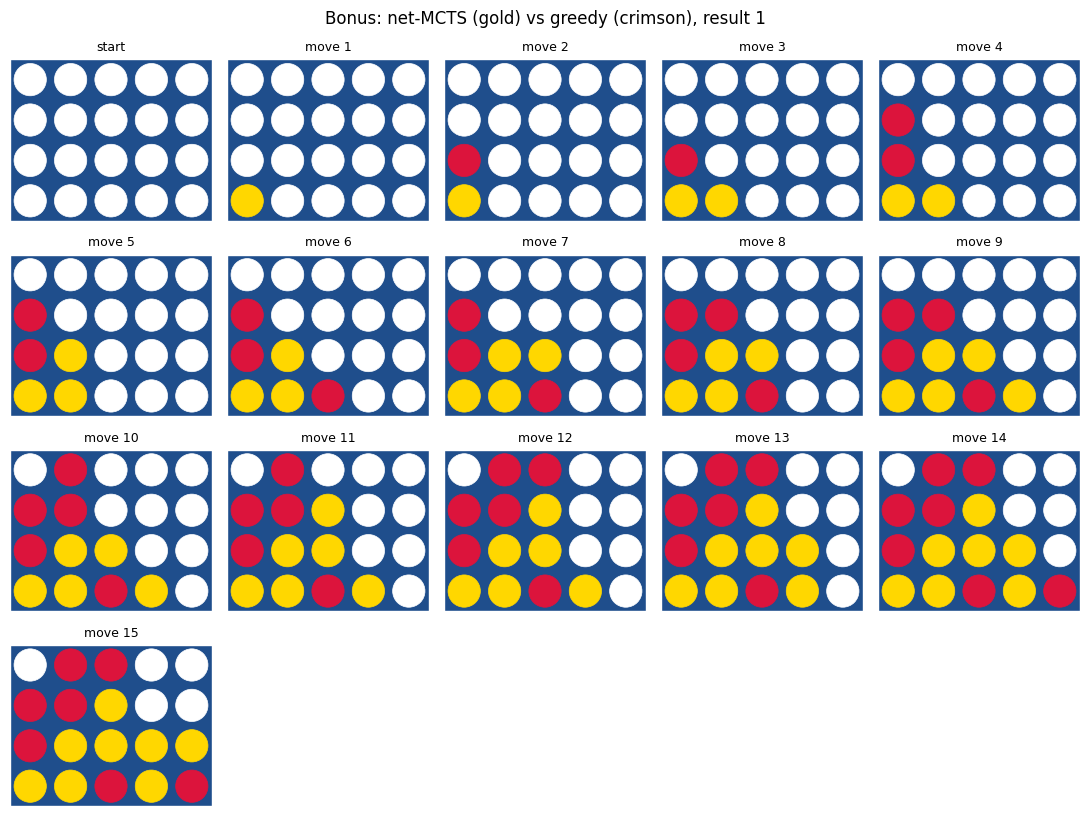

In [ ]:
random.seed(SEED)
game = ConnectFour()
frames = [game.board.copy()]
agents = {1: mcts_net_player(c4_net, SELFPLAY_SIMS), -1: greedy_player}
while game.winner() is None:
    game.play(agents[game.player](game))
    frames.append(game.board.copy())

n_frames = len(frames)
n_cols = 5
n_rows = math.ceil(n_frames / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.1 * n_rows))
for i, ax in enumerate(np.array(axes).flatten()):
    if i < n_frames:
        title = "start" if i == 0 else f"move {i}"
        draw_c4_board(ax, frames[i], title)
    else:
        ax.axis("off")
plt.suptitle(f"Bonus: net-MCTS (gold) vs greedy (crimson), result {game.winner()}")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח משחק הבונוס: אפשר לעקוב פריים אחרי פריים איך הרשת משתלטת על מרכז הלוח, בונה שני איומים במקביל ומכריעה — הדגמה חזותית של היתרון שהחיפוש מונחה הרשת מחזיק על שחקן תגובתי שרואה מהלך אחד קדימה בלבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טבלאות וגרפי סיכום:</p>
<p>ריכוז התוצאות המרכזיות משני השלבים בטבלה אחת ובגרף השוואה אחד, סביב ציר אחיד: הפסדים מול שחקן מושלם באיקס עיגול, ושיעורי תוצאה מול החמדן בארבע בשורה.</p>
</div>

tic-tac-toe | pure mcts 50: losses vs perfect play 21/60
tic-tac-toe | pure mcts 200: losses vs perfect play 18/60
tic-tac-toe | net mcts 50: losses vs perfect play 5/60
tic-tac-toe | net mcts 200: losses vs perfect play 6/60


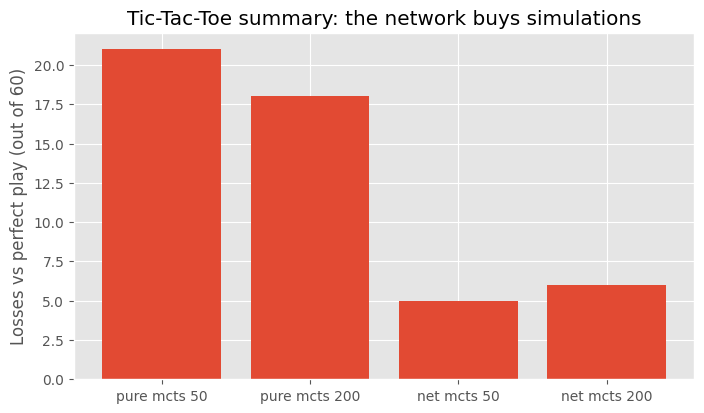

In [ ]:
random.seed(SEED)
summary_rows = []
for agent, name in ((mcts_player(50), "pure mcts 50"),
                    (mcts_player(200), "pure mcts 200"),
                    (mcts_net_player(ttt_net, 50), "net mcts 50"),
                    (mcts_net_player(ttt_net, 200), "net mcts 200")):
    wins, losses, draws = two_sided_stats(TicTacToe, agent, minimax_player, 30)
    summary_rows.append((name, losses))
    print(f"tic-tac-toe | {name}: losses vs perfect play {losses}/60")

names = [row[0] for row in summary_rows]
values = [row[1] for row in summary_rows]
plt.figure(figsize=(8, 4.5))
plt.bar(names, values)
plt.ylabel("Losses vs perfect play (out of 60)")
plt.title("Tic-Tac-Toe summary: the network buys simulations")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח סיכום: הגרף מסכם את ממצא הליבה על סביבת האימות — באותו תקציב חישוב, הוספת הרשת מפילה את מספר ההפסדים מול שחקן מושלם מעשרות לבודדים, וההבדל הקטן שבין 50 ל-200 סימולציות עם הרשת נמצא בטווח רעש הדגימה של 60 משחקים — הרשת קרובה לתקרת הביצועים כבר בתקציב הקטן. בארבע בשורה נצפתה אותה מגמה בקרב הישיר בתקציב שווה. התשובה לשאלת המחקר: ידע נלמד אכן ממיר חישוב — רשת קטנה שאומנה בדקות בודדות שווה הכפלה ואף יותר של תקציב הסימולציות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מגבלות העבודה ורעיונות לשיפור עתידי:</p>
<ul>
<li>היקף האימון קצר — דקות בודדות על מעבד; אימון ארוך יותר, מאגר גדול יותר והערכת שערים בין דורות (קבלת רשת חדשה רק אם ניצחה את קודמתה) צפויים לשפר את הרשת בארבע בשורה גם מול תקציבים גדולים</li>
<li>הרשת מלאה ופשוטה ואינה מנצלת את המבנה המרחבי של הלוח; רשת קונבולוציה צפויה להכליל טוב יותר, במיוחד בלוחות גדולים</li>
<li>ארבע בשורה המוקטן נוטה לתיקו, מה שדוחס את טווח המדידה בין סוכנים חזקים; לוח 6 על 7 המלא היה מבחין טוב יותר במחיר זמן ריצה</li>
<li>לא נוצלו סימטריות הלוח להכפלת הדאטה — שיקוף אופקי בארבע בשורה ושמונה סימטריות באיקס עיגול</li>
<li>מעקב אחר RMSE של ראש הערך מול ערכי minimax לאורך סבבי האימון, באמצעות שמירת נקודות ביקורת של הרשת</li>
<li>השוואה מול אלגוריתם מוכר נוסף מהקורס, כמו Q-Learning טבלאי על איקס עיגול, הייתה ממקמת את התוצאות בהקשר רחב יותר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום כולל:</p>
<p>הפרויקט מימש מאפס את MCTS, אימת אותו על איקס עיגול מול פתרון מושלם — כולל התכנסות מדודה לאפס הפסדים עם גידול התקציב — והדגים על ארבע בשורה מוקטן שליטה ברורה בשחקני הבסיס עם אבלציה רב-זרעית של תקציב החיפוש. בשלב השני נבנתה לולאת למידה ממשחק עצמי בהשראת AlphaZero: רשת policy ו-value שאומנה בלמידה מפוקחת על תוצרי החיפוש עצמו. הרשת צמצמה את ההפסדים מול שחקן מושלם באיקס עיגול לבודדים עד אפס, לעומת כ-20 הפסדים של החיפוש הטהור באותם תקציבים, וגברה עליו בתקציב שווה בארבע בשורה. הממצא המרכזי: העברת ידע מהחיפוש אל פונקציה נלמדת היא דרך יעילה להמיר זמן חישוב בזמן אימון — הרעיון שבבסיס AlphaZero, משוחזר בקטן על לפטופ.</p>
</div>